In [1]:

import datetime
from hmac import digest_size

import numpy as np
import cv2
from itertools import cycle
import pickle
import pathlib
import math
import tqdm
import scipy.io
from matplotlib import pyplot as plt
import scipy.io
import h5py
import re
from lxml import etree as ET
import scipy.signal as sig
import pandas as pd
from scipy.stats import kde
from BlockSync_current import BlockSync
import UtilityFunctions_newOE as uf
from scipy import signal
import bokeh
import seaborn as sns
from matplotlib import rcParams
%matplotlib inline
plt.style.use('default')
rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded and editable
rcParams['ps.fonttype'] = 42  # Ensure compatibility with vector outputs


def bokeh_plotter(data_list, x_axis_list=None, label_list=None,
                  plot_name='default',
                  x_axis_label='X', y_axis_label='Y',
                  peaks=None, peaks_list=False, export_path=False):
    """Generates an interactive Bokeh plot for the given data vector.
    Args:
        data_list (list or array): The data to be plotted.
        label_list (list of str): The labels of the data vectors
        plot_name (str, optional): The title of the plot. Defaults to 'default'.
        x_axis (str, optional): The label for the x-axis. Defaults to 'X'.
        y_axis (str, optional): The label for the y-axis. Defaults to 'Y'.
        peaks (list or array, optional): Indices of peaks to highlight on the plot. Defaults to None.
        export_path (False or str): when set to str, will output the resulting html fig
    """
    color_cycle = cycle(bokeh.palettes.Category10_10)
    fig = bokeh.plotting.figure(title=f'bokeh explorer: {plot_name}',
                                x_axis_label=x_axis_label,
                                y_axis_label=y_axis_label,
                                plot_width=1500,
                                plot_height=700)

    for i, data_vector in enumerate(data_list):

        color = next(color_cycle)

        if x_axis_list is None:
            x_axis = range(len(data_vector))
        elif len(x_axis_list) == len(data_list):
            print('x_axis manually set')
            x_axis = x_axis_list[i]
        else:
            raise Exception('problem with x_axis_list input - should be either None, or a list with the same length as data_list')
        if label_list is None:
            fig.line(x_axis, data_vector, line_color=color, legend_label=f"Line {i+1}")
        elif len(label_list) == len(data_list):
            fig.line(range(len(data_vector)), data_vector, line_color=color, legend_label=f"{label_list[i]}")
        if peaks is not None and peaks_list is True:
            fig.circle(peaks[i], data_vector[peaks[i]], size=10, color=color)

    if peaks is not None and peaks_list is False:
        fig.circle(peaks, data_vector[peaks], size=10, color='red')

    if export_path is not False:
        print(f'exporting to {export_path}')
        bokeh.io.output.output_file(filename=str(export_path / f'{plot_name}.html'), title=f'{plot_name}')
    bokeh.plotting.show(fig)


def load_eye_data_2d_w_rotation_matrix(block):
    """
    This function checks if the eye dataframes and rotation dict object exist, then imports them
    :param block: The current blocksync class with verifiec re/le dfs
    :return: None
    """
    try:
        block.left_eye_data = pd.read_csv(block.analysis_path / 'left_eye_data.csv', index_col=0, engine='python')
        block.right_eye_data = pd.read_csv(block.analysis_path / 'right_eye_data.csv', index_col=0, engine='python')
    except FileNotFoundError:
        print('eye_data files not found, run the pipeline!')
        return

    try:
        with open(block.analysis_path / 'rotate_eye_data_params.pkl', 'rb') as file:
            rotation_dict = pickle.load(file)
            block.left_rotation_matrix = rotation_dict['left_rotation_matrix']
            block.right_rotation_matrix = rotation_dict['right_rotation_matrix']
            block.left_rotation_angle = rotation_dict['left_rotation_angle']
            block.right_rotation_angle = rotation_dict['right_rotation_angle']
    except FileNotFoundError:
        print('No rotation matrix file, create it')


def create_saccade_events_df(eye_data_df, speed_threshold, bokeh_verify_threshold=False, magnitude_calib=1, speed_profile=True):
    """
    Detects saccade events in eye tracking data and computes relevant metrics.

    Parameters:
    - eye_data_df (pd.DataFrame): Input DataFrame containing eye tracking data.
    - speed_threshold (float): Threshold for saccade detection based on speed.

    Returns:
    - df (pd.DataFrame): Modified input DataFrame with added columns for speed and saccade detection.
    - saccade_events_df (pd.DataFrame): DataFrame containing information about detected saccade events.

    Steps:
    1. Calculate speed components ('speed_x', 'speed_y') based on differences in 'center_x' and 'center_y'.
    2. Compute the magnitude of the velocity vector ('speed_r').
    3. Create a binary column ('is_saccade') indicating saccade events based on the speed threshold.
    4. Determine saccade onset and offset indices and timestamps.
    5. Create a DataFrame ('saccade_events_df') with columns:
        - 'saccade_start_ind': Indices of saccade onset.
        - 'saccade_start_timestamp': Timestamps corresponding to saccade onset.
        - 'saccade_end_ind': Indices of saccade offset.
        - 'saccade_end_timestamp': Timestamps corresponding to saccade offset.
        - 'length': Duration of each saccade event.
    6. Calculate distance traveled and angles for each saccade event.
    7. Append additional columns to 'saccade_events_df':
        - 'magnitude': Magnitude of the distance traveled during each saccade.
        - 'angle': Angle of the saccade vector in degrees.
        - 'initial_x', 'initial_y': Initial coordinates of the saccade.
        - 'end_x', 'end_y': End coordinates of the saccade.

    Note: The original 'eye_data_df' is not modified; modified data is returned as 'df'.
    """
    df = eye_data_df
    df['speed_x'] = df['center_x'].diff()  # Difference between consecutive 'center_x' values
    df['speed_y'] = df['center_y'].diff()  # Difference between consecutive 'center_y' values

    # Step 2: Calculate magnitude of the velocity vector (R vector speed)
    df['speed_r'] = (df['speed_x']**2 + df['speed_y']**2)**0.5

    # Create a column for saccade detection
    df['is_saccade'] = df['speed_r'] > speed_threshold

    # create a saccade_on_off indicator where 1 is rising edge and -1 is falling edge by subtracting a shifted binary mask
    saccade_on_off = df.is_saccade.astype(int) - df.is_saccade.shift(periods=1,fill_value=False).astype(int)
    saccade_on_inds = np.where(saccade_on_off == 1)[0] - 1 # notice the manual shift here, chosen to include the first (sometimes slower) eye frame, just before saccade threshold crossing
    saccade_on_ms = df['ms_axis'].iloc[saccade_on_inds]
    saccade_on_timestamps = df['OE_timestamp'].iloc[saccade_on_inds]
    saccade_off_inds = np.where(saccade_on_off == -1)[0]
    saccade_off_timestamps = df['OE_timestamp'].iloc[saccade_off_inds]
    saccade_off_ms = df['ms_axis'].iloc[saccade_off_inds]

    saccade_dict = {'saccade_start_ind' :  saccade_on_inds ,
                    'saccade_start_timestamp': saccade_on_timestamps.values,
                    'saccade_end_ind':      saccade_off_inds,
                    'saccade_end_timestamp':saccade_off_timestamps.values,
                    'saccade_on_ms': saccade_on_ms.values,
                    'saccade_off_ms': saccade_off_ms.values}

    saccade_events_df = pd.DataFrame.from_dict(saccade_dict)
    saccade_events_df['length'] = saccade_events_df['saccade_end_ind'] - saccade_events_df['saccade_start_ind']
    # Drop columns used for intermediate steps
    df = df.drop(['is_saccade'], axis=1)

    distances = []
    angles = []
    speed_list = []
    speed_list_calib = []
    diameter_list = []
    for index, row in tqdm.tqdm(saccade_events_df.iterrows()):
        saccade_samples = df.loc[(df['OE_timestamp'] >= row['saccade_start_timestamp']) &
                                 (df['OE_timestamp'] <= row['saccade_end_timestamp'])]
        distance_traveled = saccade_samples['speed_r'].sum()
        if speed_profile:
            saccade_speed_profile = saccade_samples['speed_r'].values
            saccade_calib_speed_profile = saccade_samples['speed_r'].values * magnitude_calib
            speed_list.append(saccade_speed_profile)
            speed_list_calib.append(saccade_calib_speed_profile)
        saccade_diameter_profile = saccade_samples['pupil_diameter'].values
        diameter_list.append(saccade_diameter_profile)
        # Calculate angle from initial position to endpoint
        initial_position = saccade_samples.iloc[0][['center_x', 'center_y']]
        endpoint = saccade_samples.iloc[-1][['center_x', 'center_y']]
        overall_angle = np.arctan2(endpoint['center_y'] - initial_position['center_y'],
                           endpoint['center_x'] - initial_position['center_x'])

        angles.append(overall_angle)
        distances.append(distance_traveled)



    saccade_events_df['magnitude_raw'] = np.array(distances)
    saccade_events_df['magnitude'] = np.array(distances) * magnitude_calib
    saccade_events_df['angle'] = np.where(np.isnan(angles), angles, np.rad2deg(angles) % 360) # Convert radians to degrees and ensure result is in [0, 360)
    start_ts = saccade_events_df['saccade_start_timestamp'].values
    end_ts = saccade_events_df['saccade_end_timestamp'].values
    saccade_start_df = df[df['OE_timestamp'].isin(start_ts)]
    saccade_end_df = df[df['OE_timestamp'].isin(end_ts)]
    start_x_coord = saccade_start_df['center_x']
    start_y_coord = saccade_start_df['center_y']
    end_x_coord = saccade_end_df['center_x']
    end_y_coord = saccade_end_df['center_y']
    saccade_events_df['initial_x'] = start_x_coord.values
    saccade_events_df['initial_y'] = start_y_coord.values
    saccade_events_df['end_x'] = end_x_coord.values
    saccade_events_df['end_y'] = end_y_coord.values
    saccade_events_df['calib_dx'] = (saccade_events_df['end_x'].values - saccade_events_df['initial_x'].values) * magnitude_calib
    saccade_events_df['calib_dy'] = (saccade_events_df['end_y'].values - saccade_events_df['initial_y'].values) * magnitude_calib
    if speed_profile:
        saccade_events_df['speed_profile'] = speed_list
        saccade_events_df['speed_profile_calib'] = speed_list_calib
    saccade_events_df['diameter_profile'] = diameter_list
    if bokeh_verify_threshold:
        bokeh_plotter(data_list=[df.speed_r], label_list=['Pupil Velocity'], peaks=saccade_on_inds)

    return df, saccade_events_df


In [2]:

# create a multi-animal block_collection:

def create_block_collections(animals, block_lists, experiment_path, bad_blocks=None):
    """
    Create block collections and a block dictionary from multiple animals and their respective block lists.

    Parameters:
    - animals: list of str, names of the animals.
    - block_lists: list of lists of int, block numbers corresponding to each animal.
    - experiment_path: pathlib.Path, path to the experiment directory.
    - bad_blocks: list of int, blocks to exclude. Default is an empty list.

    Returns:
    - block_collection: list of BlockSync objects for all specified blocks.
    - block_dict: dictionary where keys are block numbers as strings and values are BlockSync objects.
    """
    import UtilityFunctions_newOE as uf

    if bad_blocks is None:
        bad_blocks = []

    block_collection = []
    block_dict = {}

    for animal, blocks in zip(animals, block_lists):
        # Generate blocks for the current animal
        current_blocks = uf.block_generator(
            block_numbers=blocks,
            experiment_path=experiment_path,
            animal=animal,
            bad_blocks=bad_blocks
        )
        # Add to collection and dictionary
        block_collection.extend(current_blocks)
        for b in current_blocks:
            block_dict[f"{animal}_block_{b.block_num}"] = b

    return block_collection, block_dict






In [3]:

animals = ['PV_106','PV_143','PV_62','PV_126', 'PV_57']
block_lists = [[8,9,10,11,12],[1,2,3,4],[24, 26, 38],[7, 8, 9, 10, 11, 12], [7, 8, 9, 12, 13]]

experiment_path = pathlib.Path(r"Z:\Nimrod\experiments")
bad_blocks = [0]  # Example of bad blocks

block_collection, block_dict = create_block_collections(
    animals=animals,
    block_lists=block_lists,
    experiment_path=experiment_path,
    bad_blocks=bad_blocks)

instantiated block number 008 at Path: Z:\Nimrod\experiments\PV_106\2025_08_06\block_008, new OE version
Found the sample rate for block 008 in the xml file, it is 20000 Hz
created the .oe_rec attribute as an open ephys recording obj with get_data functionality
retrieving zertoh sample number for block 008
got it!
instantiated block number 009 at Path: Z:\Nimrod\experiments\PV_106\2025_08_06\block_009, new OE version
Found the sample rate for block 009 in the xml file, it is 20000 Hz
created the .oe_rec attribute as an open ephys recording obj with get_data functionality
retrieving zertoh sample number for block 009
got it!
instantiated block number 010 at Path: Z:\Nimrod\experiments\PV_106\2025_08_06\block_010, new OE version
Found the sample rate for block 010 in the xml file, it is 20000 Hz
created the .oe_rec attribute as an open ephys recording obj with get_data functionality
retrieving zertoh sample number for block 010
got it!
instantiated block number 011 at Path: Z:\Nimrod\exp

In [4]:
for block in block_collection:
    block.parse_open_ephys_events()
    block.get_eye_brightness_vectors()
    block.synchronize_block()
    block.create_eye_brightness_df(threshold_value=20)

    # if the code fails here, go to manual synchronization
    block.import_manual_sync_df()
    block.read_dlc_data()
    block.calibrate_pixel_size(10)
    load_eye_data_2d_w_rotation_matrix(block) #should be integrated again... later

# # NOTICE THE DIRECTIONALITY FLIP!!!
#     block.left_eye_data = horizontal_flip_eye_data(block.left_eye_data.copy(),640)
#     block.right_eye_data = horizontal_flip_eye_data(block.right_eye_data.copy(),640)
    # calibrate pupil diameter:
for block in block_collection:
    block.left_eye_data = pd.read_csv(block.analysis_path / f'left_eye_data_degrees_raw_verified.csv')
    block.right_eye_data = pd.read_csv(block.analysis_path / 'right_eye_data_degrees_raw_verified.csv')



running parse_open_ephys_events...
block 008 has a parsed events file, reading...
Getting eye brightness values for block 008...
Found an existing file!
Eye brightness vectors generation complete.
blocksync_df loaded from analysis folder
eye_brightness_df loaded from analysis folder
eye dataframes loaded from analysis folder
got the calibration values from the analysis folder
running parse_open_ephys_events...
block 009 has a parsed events file, reading...
Getting eye brightness values for block 009...
Found an existing file!
Eye brightness vectors generation complete.
blocksync_df loaded from analysis folder
eye_brightness_df loaded from analysis folder
eye dataframes loaded from analysis folder
got the calibration values from the analysis folder
running parse_open_ephys_events...
block 010 has a parsed events file, reading...
Getting eye brightness values for block 010...
Found an existing file!
Eye brightness vectors generation complete.
blocksync_df loaded from analysis folder
eye_

In [5]:
 for block in block_collection:
    if 'pupil_diameter' not in block.left_eye_data.columns:
        block.left_eye_data['pupil_diameter_pixels'] = block.left_eye_data.major_ax
        block.right_eye_data['pupil_diameter_pixels'] = block.right_eye_data.major_ax
        block.left_eye_data['pupil_diameter'] = block.left_eye_data['pupil_diameter_pixels'] * block.L_pix_size
        block.right_eye_data['pupil_diameter'] = block.right_eye_data['pupil_diameter_pixels'] * block.R_pix_size

In [6]:
def create_saccade_events_with_direction_segmentation_robust(
        eye_data_df,
        speed_threshold,  # angular speed threshold in degrees/frame
        directional_delta_threshold_deg=25,  # threshold for change in instantaneous angle (degrees)
        magnitude_calib=1,
        speed_profile=True,
        min_subsaccade_samples=2,
        min_net_disp=0.5  # minimal net angular displacement (in degrees) for a segment to be valid
):
    """
    Detects and segments saccade events in eye tracking data using angular speed and directional changes.
    This robust version avoids producing segments with near-zero net displacement by:
      1. Defining the saccade onset as the first frame where the angular speed exceeds the threshold.
      2. Segmenting the event based on sustained directional changes.
      3. Discarding segments whose overall net angular displacement (computed from k_phi and k_theta)
         is below a user-specified minimal value.

    Parameters:
      - eye_data_df (pd.DataFrame): DataFrame with columns including:
            'center_x', 'center_y', 'k_phi', 'k_theta', 'OE_timestamp', 'ms_axis', 'pupil_diameter'.
      - speed_threshold (float): Angular speed threshold (degrees/frame) for detection.
      - directional_delta_threshold_deg (float): Angular change threshold to determine segmentation boundaries.
      - magnitude_calib (float): Calibration factor (not applied to angular measures).
      - speed_profile (bool): Whether to record speed profiles.
      - min_subsaccade_samples (int): Minimum number of samples required for a valid segment.
      - min_net_disp (float): Minimal net angular displacement (in degrees) required for a segment to be kept.

    Returns:
      - df (pd.DataFrame): The input DataFrame with added computed columns.
      - saccade_events_df (pd.DataFrame): DataFrame listing detected and segmented saccade events, with metrics.
    """
    # Make a copy so as not to modify the original DataFrame.
    df = eye_data_df.copy()

    ### 1. Compute Frame-to-Frame Differences
    df["speed_x"] = df["center_x"].diff()
    df["speed_y"] = df["center_y"].diff()
    df["speed_r"] = np.sqrt(df["speed_x"] ** 2 + df["speed_y"] ** 2)

    # Angular differences (k_phi and k_theta are in degrees)
    df["angular_speed_phi"] = df["k_phi"].diff()
    df["angular_speed_theta"] = df["k_theta"].diff()
    df["angular_speed_r"] = np.sqrt(df["angular_speed_phi"] ** 2 + df["angular_speed_theta"] ** 2)

    ### 2. Saccade Detection Based on Angular Speed
    # Mark frames where the instantaneous angular speed exceeds the threshold.
    df["is_saccade_angle"] = df["angular_speed_r"] > speed_threshold

    # Identify transitions to detect onsets and offsets.
    saccade_on_off = df["is_saccade_angle"].astype(int) - df["is_saccade_angle"].shift(1, fill_value=0).astype(int)
    # Use the first frame above threshold as onset
    saccade_on_inds = np.where(saccade_on_off == 1)[0]
    saccade_off_inds = np.where(saccade_on_off == -1)[0]

    # Handle mismatches: if a saccade starts but does not end, drop the last onset.
    if len(saccade_on_inds) > len(saccade_off_inds):
        saccade_on_inds = saccade_on_inds[:-1]

    saccade_events = []

    ### 3. Process Each Detected Saccade for Segmentation
    for start_ind, end_ind in zip(saccade_on_inds, saccade_off_inds):
        saccade_df = df.iloc[start_ind:end_ind + 1].copy()
        if saccade_df.empty or len(saccade_df) < min_subsaccade_samples:
            continue

        # Compute instantaneous angles (for both pixel- and angular-based estimates)
        saccade_df["inst_angle_pixel"] = np.degrees(np.arctan2(saccade_df["speed_y"], saccade_df["speed_x"]))
        saccade_df["inst_angle_deg"] = np.degrees(
            np.arctan2(saccade_df["angular_speed_theta"], saccade_df["angular_speed_phi"]))

        # Define helper function for minimal angular difference (handling circularity)
        minimal_angle_diff_deg = lambda a, b: ((a - b + 180) % 360) - 180

        angles = saccade_df["inst_angle_deg"].values
        # Compute consecutive differences
        angle_diffs = np.array([minimal_angle_diff_deg(angles[i + 1], angles[i]) for i in range(len(angles) - 1)])

        # Identify candidate segmentation boundaries when the absolute change exceeds threshold.
        candidate_boundaries = np.where(np.abs(angle_diffs) > directional_delta_threshold_deg)[0].tolist()

        # Always include the first and last frame of the saccade.
        boundaries = [0] + candidate_boundaries + [len(saccade_df) - 1]

        # Process each segment defined by these boundaries.
        for i in range(len(boundaries) - 1):
            seg_start = boundaries[i]
            seg_end = boundaries[i + 1]
            subsaccade = saccade_df.iloc[seg_start: seg_end + 1]
            if len(subsaccade) < min_subsaccade_samples:
                continue

            # Compute net angular displacement using the angular positions (k_phi and k_theta)
            initial_pos_angle = subsaccade.iloc[0][["k_phi", "k_theta"]]
            final_pos_angle = subsaccade.iloc[-1][["k_phi", "k_theta"]]
            net_disp = np.sqrt((final_pos_angle["k_phi"] - initial_pos_angle["k_phi"]) ** 2 +
                               (final_pos_angle["k_theta"] - initial_pos_angle["k_theta"]) ** 2)

            # Only record segments whose net displacement is above min_net_disp.
            if net_disp < min_net_disp:
                continue

            # Timing and indices
            sub_start_timestamp = subsaccade["OE_timestamp"].iloc[0]
            sub_end_timestamp = subsaccade["OE_timestamp"].iloc[-1]
            sub_start_ms = subsaccade["ms_axis"].iloc[0]
            sub_end_ms = subsaccade["ms_axis"].iloc[-1]
            sub_length = subsaccade.index[-1] - subsaccade.index[0]

            # Pixel-based metrics
            magnitude_raw_pixel = subsaccade["speed_r"].sum()
            magnitude_pixel = magnitude_raw_pixel * magnitude_calib

            # Angular-based metric: sum of instantaneous angular speeds
            magnitude_raw_angular = subsaccade["angular_speed_r"].sum()

            # Overall angular-based angle (from start to end)
            overall_angle_deg = (np.degrees(np.arctan2(
                final_pos_angle["k_theta"] - initial_pos_angle["k_theta"],
                final_pos_angle["k_phi"] - initial_pos_angle["k_phi"]
            )) % 360)

            # (Optional) Capture speed profiles and other details
            speed_profile_pixel = subsaccade["speed_r"].values if speed_profile else None
            speed_profile_pixel_calib = (speed_profile_pixel * magnitude_calib) if speed_profile else None
            speed_profile_angular = subsaccade["angular_speed_r"].values if speed_profile else None
            diameter_profile = subsaccade["pupil_diameter"].values

            saccade_events.append({
                "saccade_start_ind": subsaccade.index[0],
                "saccade_end_ind": subsaccade.index[-1],
                "saccade_start_timestamp": sub_start_timestamp,
                "saccade_end_timestamp": sub_end_timestamp,
                "saccade_on_ms": sub_start_ms,
                "saccade_off_ms": sub_end_ms,
                "length": sub_length,
                "magnitude_raw_pixel": magnitude_raw_pixel,
                "magnitude_pixel": magnitude_pixel,
                "magnitude_raw_angular": magnitude_raw_angular,
                "overall_angle_deg": overall_angle_deg,
                "net_angular_disp": net_disp,
                "speed_profile_pixel": speed_profile_pixel,
                "speed_profile_pixel_calib": speed_profile_pixel_calib,
                "speed_profile_angular": speed_profile_angular,
                "diameter_profile": diameter_profile,
                "theta_init_pos": initial_pos_angle["k_theta"],
                "theta_end_pos": final_pos_angle["k_theta"],
                "phi_init_pos": initial_pos_angle["k_phi"],
                "phi_end_pos": final_pos_angle["k_phi"]
            })

    # Convert the list to a DataFrame.
    saccade_events_df = pd.DataFrame(saccade_events)

    # Optionally remove intermediate column
    df.drop(["is_saccade_angle"], axis=1, inplace=True)

    # Calculate delta columns for convenience.
    if not saccade_events_df.empty:
        saccade_events_df['delta_theta'] = saccade_events_df['theta_end_pos'] - saccade_events_df['theta_init_pos']
        saccade_events_df['delta_phi'] = saccade_events_df['phi_end_pos'] - saccade_events_df['phi_init_pos']

    return df, saccade_events_df


In [7]:
for block in block_collection:
    print(block)
    block.left_eye_data, block.l_saccade_df = create_saccade_events_with_direction_segmentation_robust(block.left_eye_data,
                                                                                                        0.8,  # angular speed threshold in degrees/video frame, 0.8+~50 deg / sec
                                                                                                        directional_delta_threshold_deg=90,  # threshold for change in instantaneous angle (degrees)
                                                                                                        magnitude_calib=1,
                                                                                                        speed_profile=True,
                                                                                                        min_subsaccade_samples=2)
    block.right_eye_data, block.r_saccade_df = create_saccade_events_with_direction_segmentation_robust(block.right_eye_data,
                                                                                                        0.8,  # angular speed threshold in degrees/video frame
                                                                                                        directional_delta_threshold_deg=90,  # threshold for change in instantaneous angle (degrees)
                                                                                                        magnitude_calib=1,
                                                                                                        speed_profile=True,
                                                                                                        min_subsaccade_samples=2)


PV_106, block 008, on PV106_ET_d3t12025-08-06_11-52-19
PV_106, block 009, on PV106_ET_d3t2_2025-08-06_12-09-43
PV_106, block 010, on PV106_ET_d3t3_2025-08-06_12-26-43
PV_106, block 011, on PV106_ET_d3t4_2025-08-06_12-44-30
PV_106, block 012, on PV106_ET_d3t5_2025-08-06_13-21-30
PV_143, block 001, on PV143_ET_d1t1_2025-08-11_13-29-08
PV_143, block 002, on PV143_ET_d1t2_2025-08-11_13-50-11
PV_143, block 003, on PV143_ET_d1t3_2025-08-11_14-20-35
PV_143, block 004, on PV143_ET_d1t4_2025-08-11_14-58-28
PV_62, block 024, on 2023-04-27_11-22-56
PV_62, block 026, on 2023-04-27_12-21-41
PV_62, block 038, on 2023-05-01_13-57-45
PV_126, block 007, on PV126_Trial16_wake3_2024-07-18_12-49-12
PV_126, block 008, on PV126_Trial16_wake4_2024-07-18_13-24-41
PV_126, block 009, on PV126_Trial18_wake5_2024-07-18_14-39-15
PV_126, block 010, on PV126_Trial19_wake6_2024-07-18_15-24-57
PV_126, block 011, on PV126_Trial115_eyeTracking_w7
PV_126, block 012, on PV126_Trial116_eyeTracking_h8
PV_57, block 007, on p

In [8]:
### over here, I get the lizard movements binary from mark's analysis
import os
def block_get_lizard_movement(block):
    p = block.oe_path / 'analysis'
    analysis_list = os.listdir(p)
    correct_analysis = [i for i in analysis_list if block.animal_call in i][0]
    p = p / str(correct_analysis)
    mat_path = p / 'lizMov.mat'
    print(f'path to mat file is {mat_path}')
    # read mat file
    try:
        mat_data = h5py.File(str(mat_path), 'r')
        mat_dict = {'t_mov_ms': mat_data['t_mov_ms'][:],
                    'movAll': mat_data['movAll'][:],
                    'angles': mat_data['angles'][:],
                    'staticAll': mat_data['staticAll'][:],
                    't_static_ms': mat_data['t_static_ms'][:]}
        mat_dict['phi_rad'] = mat_dict['angles'][:,0]
        mat_dict['theta_rad'] = mat_dict['angles'][:,1]
        mat_dict['theta_deg'] = np.rad2deg(mat_dict['theta_rad'])
        mat_dict['phi_deg'] = np.rad2deg(mat_dict['phi_rad'])
        acc_df = pd.DataFrame(data=np.array([mat_dict['t_mov_ms'][:, 0], mat_dict['movAll'][:, 0]]).T,
                              columns=['t_mov_ms', 'movAll'])
        static_df = pd.DataFrame(data=np.array([mat_dict['t_static_ms'][:, 0],
                                                mat_dict['staticAll'][:, 0],
                                                mat_dict['phi_rad'],
                                                mat_dict['theta_rad'],
                                                mat_dict['phi_deg'],
                                                mat_dict['theta_deg']]).T,
                              columns=['t_static_ms', 'staticAll','phi_rad','theta_rad','phi_deg','theta_deg'])
        mat_data.close()
        block.liz_mov_df = acc_df
        block.liz_static_df = static_df
        print(f'liz_mov_df created for {block}')
    except FileNotFoundError:
        print(f'no such file {mat_path}')


# this cell now labels the saccades as with/without head movements
def get_head_mov_col(df, mov_times):
    head_mov_bool = np.zeros(len(df), dtype=bool)  # Initialize array of False

    for i, saccade in enumerate(df.itertuples()):
        saccade_start = saccade.saccade_on_ms
        saccade_end = saccade.saccade_off_ms

        overlapping_mov_times = mov_times[np.logical_and(mov_times >= saccade_start, mov_times <= saccade_end)]

        if overlapping_mov_times.size > 0:
            head_mov_bool[i] = True

    df['head_movement'] = head_mov_bool
    return df

def label_saccade_movements(block):
    mov_times = block.liz_mov_df.t_mov_ms.values
    block.l_saccade_df = get_head_mov_col(block.l_saccade_df,mov_times=mov_times)
    block.r_saccade_df = get_head_mov_col(block.r_saccade_df,mov_times=mov_times)

# Create a list to store blocks where movement data exists
block_collection_w_mov = []

for block in block_collection:
    try:
        block_get_lizard_movement(block)  # Try loading movement data
        label_saccade_movements(block)    # Try labeling saccades

        # If both steps succeed, add block to the valid collection
        block_collection_w_mov.append(block)

    except (FileNotFoundError, OSError) as e:
        print(f"Skipping block {block}: {str(e)}")  # Notify which block failed


path to mat file is Z:\Nimrod\experiments\PV_106\2025_08_06\block_008\oe_files\PV106_ET_d3t12025-08-06_11-52-19\Record Node 102\analysis\recNames=Block008,Animal=PV_106\lizMov.mat
liz_mov_df created for PV_106, block 008, on PV106_ET_d3t12025-08-06_11-52-19
path to mat file is Z:\Nimrod\experiments\PV_106\2025_08_06\block_009\oe_files\PV106_ET_d3t2_2025-08-06_12-09-43\Record Node 102\analysis\recNames=Block009,Animal=PV_106\lizMov.mat
liz_mov_df created for PV_106, block 009, on PV106_ET_d3t2_2025-08-06_12-09-43
path to mat file is Z:\Nimrod\experiments\PV_106\2025_08_06\block_010\oe_files\PV106_ET_d3t3_2025-08-06_12-26-43\Record Node 102\analysis\recNames=Block010,Animal=PV_106\lizMov.mat
liz_mov_df created for PV_106, block 010, on PV106_ET_d3t3_2025-08-06_12-26-43
path to mat file is Z:\Nimrod\experiments\PV_106\2025_08_06\block_011\oe_files\PV106_ET_d3t4_2025-08-06_12-44-30\Record Node 102\analysis\recNames=Block011,Animal=PV_106\lizMov.mat
liz_mov_df created for PV_106, block 011,

In [9]:
import os
import pickle
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def plot_saccade_magnitude_vs_velocity_time_to_peak_angular(
    synced_saccade_collection, monocular_saccade_collection, export_path=None, threshold=3,
    fig_size=(3, 3), velocity_threshold=None, velocity_to_deg_per_ms=True, frame_rate_fps=60
):
    """
    Plots angular saccade magnitudes versus angular peak velocities as a compact scatter plot.
    Angular metrics are extracted from the synchronized saccade DataFrame:
      - Angular amplitude is taken from 'magnitude_raw_angular'
      - Peak angular velocity is computed as the maximum value from 'speed_profile_angular'
      - Time-to-peak is assumed to be stored in 'time_to_peak_v'

    Parameters:
      - synced_saccade_collection: DataFrame of synchronized saccades containing angular columns.
      - monocular_saccade_collection: DataFrame of monocular saccades (unused here, but kept for compatibility).
      - export_path (str): Directory path to export the plot and data.
      - threshold (float): Standard deviation threshold for outlier removal.
      - fig_size (tuple): Figure size (width, height).
      - velocity_threshold (float): Optional horizontal line value for peak velocities.
      - velocity_to_deg_per_ms (bool): If True, convert angular speeds from deg/frame to deg/ms.
      - frame_rate_fps (float): Frame rate in frames per second.
    """

    def extract_saccade_metrics_time_to_peak_angular(saccade_collection, eye_label):
        """
        Extracts angular saccade metrics for the given eye.
        Assumes that saccade_collection contains:
          - 'magnitude_raw_angular': angular amplitude (deg)
          - 'speed_profile_angular': list/array of angular speeds (deg/frame)
          - 'time_to_peak_v': time to reach peak angular speed (ms)
        """
        filtered_data = saccade_collection.query('eye == @eye_label')
        magnitudes = filtered_data['magnitude_raw_angular'].values
        # Compute peak angular speed (in deg/frame) from the angular speed profile
        peak_velocities = np.array([np.nanmax(profile) for profile in filtered_data['speed_profile_angular']])
        time_to_peak = filtered_data['time_to_peak_v'].values
        return magnitudes, peak_velocities, time_to_peak

    # Get metrics for left and right eyes
    l_magnitudes, l_peak_velocities, l_time_to_peak = extract_saccade_metrics_time_to_peak_angular(synced_saccade_collection, 'L')
    r_magnitudes, r_peak_velocities, r_time_to_peak = extract_saccade_metrics_time_to_peak_angular(synced_saccade_collection, 'R')

    # Concatenate the data from both eyes
    all_magnitudes = np.concatenate((l_magnitudes, r_magnitudes))
    all_peak_velocities = np.concatenate((l_peak_velocities, r_peak_velocities))
    all_time_to_peaks = np.concatenate((l_time_to_peak, r_time_to_peak))

    # Convert from deg/frame to deg/ms if requested
    frame_duration = 1000 / frame_rate_fps  # ms per frame
    if velocity_to_deg_per_ms:
        all_peak_velocities = all_peak_velocities / frame_duration

    # Combine into DataFrame
    data = pd.DataFrame({
        'magnitude': all_magnitudes,           # Angular amplitude in degrees
        'peak_velocity': all_peak_velocities,   # Angular peak velocity in deg/ms
        'time_to_peak': all_time_to_peaks         # Time to peak (ms)
    })

    # Remove outliers (this function should be defined elsewhere)
    cleaned_data = remove_outliers_from_df(data, threshold)

    # Extract cleaned data for plotting
    f_magnitudes = cleaned_data['magnitude'].values
    f_peak_velocities = cleaned_data['peak_velocity'].values
    f_time_to_peaks = cleaned_data['time_to_peak'].values

    # Create scatter plot
    fig, ax = plt.subplots(figsize=fig_size, dpi=300)
    sc = ax.scatter(f_magnitudes, f_peak_velocities, s=0.7, c=f_time_to_peaks, cmap='viridis', alpha=0.7)

    ax.set_xlabel('Angular Amplitude [deg]', fontsize=10)
    ax.set_ylabel('Peak Angular Velocity [deg/ms]', fontsize=10)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

    if velocity_threshold is not None:
        ax.axhline(y=velocity_threshold, color='red', linestyle='--', linewidth=1.5)

    # Add a limiting slope line (here, a line with slope = 1/frame_duration as a reference)
    limiting_slope = 1 / frame_duration
    x_line = np.linspace(0, f_magnitudes.max(), 100)
    y_line = limiting_slope * x_line
    ax.plot(x_line, y_line, color='orange', linestyle='--', linewidth=1.5, label='Min Detectable Speed')
    ax.legend(fontsize=8)

    # Add colorbar for time-to-peak
    cbar = plt.colorbar(sc, ax=ax, pad=0.02, aspect=10)
    cbar.set_label('Time-To-Peak [ms]', fontsize=8)
    cbar.ax.tick_params(labelsize=8)

    # Export plot and data if export_path is provided
    if export_path is not None:
        timestamp = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
        full_export_path = os.path.join(export_path, f"saccade_magnitude_vs_velocity_time_to_peak_angular_{timestamp}")
        os.makedirs(full_export_path, exist_ok=True)
        pdf_file = os.path.join(full_export_path, "saccade_magnitude_vs_velocity_time_to_peak_angular.pdf")
        fig.savefig(pdf_file, format='pdf', bbox_inches='tight', dpi=300)
        data_file = os.path.join(full_export_path, "cleaned_saccade_data_time_to_peak_angular.pkl")
        with open(data_file, 'wb') as f:
            pickle.dump(cleaned_data, f)
        print(f"Exported plot and data to: {full_export_path}")

    plt.show()


In [10]:
# add annotations for a joint dataframe:
for block in block_collection:
    block.r_saccade_df['eye'] = 'R'
    block.r_saccade_df['block'] = block.block_num
    block.r_saccade_df['animal'] = block.animal_call
    block.l_saccade_df['eye'] = 'L'
    block.l_saccade_df['block'] = block.block_num
    block.l_saccade_df['animal'] = block.animal_call
    block.all_saccade_df = pd.concat([block.l_saccade_df,block.r_saccade_df])

In [11]:
saccade_df_list = []
for block in block_collection:
    saccade_df_list.append(block.all_saccade_df)
saccade_collection = pd.concat(saccade_df_list)

In [12]:
def get_closest_diff_ind(timestamp, timeseries):
    """
    This function extracts a frame from a series so that it is as close as possible to a given timestamp
    :param timestamp: The time to match a frame to
    :param timeseries: The time frames series to look at for a match
    :param report_acc: if set to 1, will report the accuracy of the match
    :return: index_of_lowest_diff , accuracy of match (if requested)
    """
    array = np.abs(timeseries - timestamp)
    index_of_lowest_diff = np.argmin(array)
    lowest_diff_val = timeseries[index_of_lowest_diff]
    return index_of_lowest_diff, lowest_diff_val

def find_synced_saccades(df, diff_threshold=680):
    synced_saccades = []
    non_synced_saccades = []
    l_df = df.query('eye == "L"')
    r_df = df.query('eye == "R"')
    for i, row in tqdm.tqdm(l_df.iterrows()):
        l_timestamp = row['saccade_start_timestamp']
        ind_min_diff, r_timestamp = get_closest_diff_ind(l_timestamp, r_df['saccade_start_timestamp'].values)
        #print(i,ind_lowest_diff)
        time_diff = np.abs(l_timestamp - r_timestamp)
        if time_diff < diff_threshold:
            synced_saccades.append((row, r_df.iloc[ind_min_diff]))  # Collect synchronized rows
        else:
            non_synced_saccades.append(row)  # Collect non-synchronized rows
    # Create DataFrame with multi-index
    multi_index = pd.MultiIndex.from_tuples([(i, 'L') for i in range(len(synced_saccades))] + [(i, 'R') for i in range(len(synced_saccades))], names=['Main', 'Sub'])
    synced_df = pd.DataFrame(index=multi_index, columns=df.columns)
    # Populate DataFrame
    for idx, (l_row, r_row) in enumerate(synced_saccades):
        synced_df.loc[(idx, 'L')] = l_row
        synced_df.loc[(idx, 'R')] = r_row
    r_non_synced_leftovers = r_df[~r_df['saccade_start_timestamp'].isin(synced_df.query('eye == "R"')['saccade_start_timestamp'].values)]
    print(len(r_non_synced_leftovers),len(r_df))
    # Create DataFrame for non-synced saccades
    non_synced_df = pd.DataFrame(non_synced_saccades, columns=df.columns)
    non_synced_df = pd.concat([non_synced_df,r_non_synced_leftovers])

    return synced_df, non_synced_df

synced_df_list = []
non_synced_df_list = []
for saccade_df in saccade_df_list:
    # Find synced saccades:
    synced_df, non_synced_df = find_synced_saccades(saccade_df.dropna(), diff_threshold=680)
    if len(non_synced_df.dropna()) + len(synced_df.dropna()) == len(saccade_df.dropna()):
        print('got them all')

    synced_df_list.append(synced_df)
    non_synced_df_list.append(non_synced_df)


924it [00:00, 7994.04it/s]
395it [00:00, 7390.60it/s]
472it [00:00, 10069.18it/s]

105 517
102 336



1273it [00:00, 8651.73it/s]

103 320



724it [00:00, 8557.13it/s]
0it [00:00, ?it/s]

...

1635 2183



794it [00:00, 7914.87it/s]

461 1087
487 888



786it [00:00, 6779.43it/s]
999it [00:00, 6787.32it/s]


286 763
573 1245


In [13]:
def combine_synced_dataframes(dataframes):
    combined_dfs = []
    start_index = 0
    for df in dataframes:
        num_rows = len(df) // 2  # Assuming each dataframe contains pairs of rows
        main_index = pd.MultiIndex.from_tuples([(i + start_index, 'L') for i in range(num_rows)] + [(i + start_index, 'R') for i in range(num_rows)], names=['Main', 'Sub'])
        df.index = main_index
        combined_dfs.append(df)
        start_index += num_rows
    combined_df = pd.concat(combined_dfs)
    combined_df.reset_index(inplace=True)
    return combined_df

synced_saccade_collection = combine_synced_dataframes(synced_df_list)
non_synced_saccade_collection = pd.concat(non_synced_df_list)


In [14]:
all_saccade_collection = pd.concat([synced_saccade_collection,non_synced_saccade_collection])


In [15]:


# This one in progress
# ---------- imports ----------
import datetime
import pickle
from pathlib import Path
from typing import Optional, Tuple, Sequence, Dict, Any, List, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from scipy.ndimage import gaussian_filter1d

# ---------- helpers ----------

def _ensure_dir(p: Union[str, Path]) -> Path:
    p = Path(p)
    p.mkdir(parents=True, exist_ok=True)
    return p

def _save_legend_as_pdf(ax: plt.Axes, out_path: Union[str, Path], ncol=2, fontsize=6, frameon=False):
    leg = ax.legend(frameon=frameon, fontsize=fontsize, ncol=ncol)
    if leg is None:
        return
    fig_leg = leg.figure
    fig_leg.canvas.draw()
    fig_leg.savefig(out_path, bbox_inches="tight", dpi=300)

def _block_key(animal, block_num):
    return f"{animal}_block_{int(block_num):03d}", f"{animal}_block_{int(block_num)}"

def _eye_df(block_dict, animal, block_num, eye):
    k1, k2 = _block_key(animal, block_num)
    blk = block_dict.get(k1, block_dict.get(k2, None))
    if blk is None:
        raise KeyError(f"Block not found for {animal} block {block_num} (tried {k1} / {k2})")
    df = blk.left_eye_data if str(eye).upper() == "L" else blk.right_eye_data
    need = {"ms_axis","k_phi","k_theta"}
    if not need.issubset(df.columns):
        raise ValueError(f"Eye dataframe missing columns: {need - set(df.columns)}")
    return df

def _raw_velocity_trace(df_eye):
    t = df_eye["ms_axis"].to_numpy(dtype=float)
    phi = df_eye["k_phi"].to_numpy(dtype=float)
    th  = df_eye["k_theta"].to_numpy(dtype=float)
    dphi = np.diff(phi); dth = np.diff(th); dt_s = np.diff(t) / 1000.0
    v_dps = np.divide(np.hypot(dphi, dth), dt_s, out=np.full_like(dphi, np.nan), where=dt_s>0)
    t_ms = t[1:]
    return t_ms, v_dps

def _peak_time_in_window(t_ms, v_dps, on_ms, off_ms, subsample_peak=False):
    m = (t_ms >= on_ms) & (t_ms <= off_ms) & np.isfinite(v_dps)
    if not np.any(m):
        return np.nan
    v = v_dps[m]; tloc = t_ms[m]
    i = int(np.nanargmax(v))
    if (not subsample_peak) or i == 0 or i == v.size-1:
        return float(tloc[i])
    v_1, v0, v1 = v[i-1], v[i], v[i+1]
    denom = (v_1 - 2*v0 + v1)
    if not np.isfinite(denom) or denom == 0:
        return float(tloc[i])
    d = 0.5*(v_1 - v1)/denom
    d = float(np.clip(d, -1.0, 1.0))
    dt_local = (tloc[min(i+1, v.size-1)] - tloc[max(i-1, 0)]) / 2.0
    return float(tloc[i] + d * dt_local)

def _first_cross_time(t, y, ythr):
    """Linear-interpolated first time where y(t) >= ythr. Returns None if no crossing."""
    t = np.asarray(t); y = np.asarray(y)
    if t.size < 2 or not np.isfinite(ythr): return None
    valid = np.isfinite(y)
    t = t[valid]; y = y[valid]
    if t.size < 2: return None
    y0, y1 = y[:-1], y[1:]
    t0, t1 = t[:-1], t[1:]
    s0, s1 = y0 - ythr, y1 - ythr
    cross_idx = np.where((s0 <= 0) & (s1 >= 0) | (s0 >= 0) & (s1 <= 0) | (np.isclose(y0, ythr)))[0]
    if cross_idx.size == 0:
        return None
    k = int(cross_idx[0])
    if np.isclose(y0[k], ythr):
        return float(t0[k])
    denom = (y1[k] - y0[k])
    if np.isclose(denom, 0.0):
        return float(t0[k])
    frac = (ythr - y0[k]) / denom
    frac = float(np.clip(frac, 0.0, 1.0))
    return float(t0[k] + frac * (t1[k] - t0[k]))


import datetime, pickle
from pathlib import Path
from typing import Optional, Tuple, Sequence, Dict, Any, List, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from scipy.ndimage import gaussian_filter1d


import datetime, pickle
from pathlib import Path
from typing import Optional, Tuple, Sequence, Dict, Any, List, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from scipy.ndimage import gaussian_filter1d


def plot_pos_and_vel_by_amp_bins_per_animal_kernel(
    all_saccade_collection: pd.DataFrame,
    block_dict: dict,
    # ---- core analysis params ----
    amp_col: Optional[str] = None,       # auto-pick if None
    bin_width_deg: float = 5.0,
    min_amp_deg: float = 0.5,
    t_window_ms: Tuple[float, float] = (-40.0, 80.0),
    dt_ms: float = 2.0,                  # grid step
    bandwidth_ms: float = 10.0,          # Gaussian kernel across time bins
    min_events_per_bin: int = 30,
    per_animal_max_bins: int = 8,
    eye_filter: Optional[str] = None,    # "L", "R", or None (both)
    subsample_peak: bool = False,        # sub-frame peak alignment (only relevant when align_to='peak')
    smoothing: bool = True,              # kernel smoothing (group-level)
    plot_bins_as_scatter: bool = False,  # when not smoothing, markers+line
    min_bin_count: int = 3,              # ignore sparse bins (unsmoothed)
    errorbars: bool = False,             # show SD as error bars (unsmoothed)
    normalize_velocity_to_peak: bool = False,  # divide mean V by its own peak
    normalize_position_to_amp: bool = True,    # divide pos by each event's net amp
    normalize_final_curve: bool = False,       # final 0..1 normalization of the *mean position* curve
    velocity_threshold: float = None,          # deg/s (or relative if normalized)
    # ---- NEW controls ----
    align_to: str = "peak",              # 'peak' (default) or 'onset'
    position_calc: str = "mov_axis",     # 'mov_axis' (default) or 'integrate'
    # ---- visibility & axis controls ----
    show_position: bool = True,
    show_velocity: bool = True,
    vel_ylim: Optional[Tuple[float, float]] = None,
    pos_ylim: Optional[Tuple[float, float]] = None,
    # vertical/horizontal threshold line styling
    vline_kwargs: dict = None,
    hline_kwargs: dict = None,
    # ---- export controls ----
    export_path: Optional[Union[Path, str]] = None,
    fig_size: Tuple[float, float] = (4.0, 3.6),
    dpi: int = 200,
    legend_ncol: int = 2,
    bin_cmap: str = "viridis",
    # ---- display control ----
    show_inline: bool = True
):
    """
    Two-panel figure (top: position, bottom: velocity) with optional single-panel modes.

    NEW:
      - align_to: 'peak' (t=0 at peak velocity) or 'onset' (t=0 at saccade onset).
      - position_calc:
          'mov_axis'  -> project (k_phi, k_theta) onto the event's net movement axis.
          'integrate' -> project angular velocity onto the axis and *integrate* to get position.

    Position pipeline:
      Per event -> align (peak/onset) -> sample on fixed grid -> average within amplitude bins.
      If normalize_position_to_amp: per-event position divided by that event's amplitude.
      If normalize_final_curve: per-bin *mean* position curve min-max normalized to [0,1].

    Velocity pipeline:
      Same alignment; mean ± SD across events (optional normalization to its own peak).
    """
    if not (show_position or show_velocity):
        raise ValueError("At least one of show_position or show_velocity must be True.")
    if align_to not in ("peak", "onset"):
        raise ValueError("align_to must be 'peak' or 'onset'.")
    if position_calc not in ("mov_axis", "integrate"):
        raise ValueError("position_calc must be 'mov_axis' or 'integrate'.")

    if vline_kwargs is None: vline_kwargs = dict(ls=":", lw=1.6, alpha=0.9)
    if hline_kwargs is None: hline_kwargs = dict(ls=":", lw=1.6, color="red", alpha=0.7)

    df = all_saccade_collection.reset_index(drop=True).copy()
    req = {"animal","block","eye","saccade_on_ms","saccade_off_ms"}
    if not req.issubset(df.columns):
        raise ValueError("DataFrame must have columns: %s" % (req,))

    # choose amplitude column
    if amp_col is None:
        for c in ("net_angular_disp","magnitude_raw_angular"):
            if c in df.columns:
                amp_col = c; break
    if amp_col is None:
        raise ValueError("Need 'net_angular_disp' or 'magnitude_raw_angular'.")
    df[amp_col] = pd.to_numeric(df[amp_col], errors="coerce")

    if eye_filter:
        df = df[df["eye"].str.upper() == eye_filter.upper()]

    animals = sorted(df["animal"].dropna().unique().tolist())

    tmin, tmax = float(t_window_ms[0]), float(t_window_ms[1])
    t_grid = np.arange(tmin, tmax + dt_ms, dt_ms); nb = len(t_grid)
    sigma_bins = max(1.0, float(bandwidth_ms) / float(dt_ms))
    cmap = colormaps.get_cmap(bin_cmap)

    # export root + bundle
    root_out = None
    bundle: Dict[str, Any] = {
        "t_grid": t_grid.astype(np.float32),
        "params": dict(
            amp_col=amp_col,
            bin_width_deg=bin_width_deg,
            min_amp_deg=min_amp_deg,
            t_window_ms=tuple(t_window_ms),
            dt_ms=float(dt_ms),
            bandwidth_ms=float(bandwidth_ms),
            min_events_per_bin=int(min_events_per_bin),
            per_animal_max_bins=int(per_animal_max_bins),
            eye_filter=(None if eye_filter is None else str(eye_filter)),
            subsample_peak=bool(subsample_peak),
            smoothing=bool(smoothing),
            plot_bins_as_scatter=bool(plot_bins_as_scatter),
            min_bin_count=int(min_bin_count),
            normalize_velocity_to_peak=bool(normalize_velocity_to_peak),
            normalize_position_to_amp=bool(normalize_position_to_amp),
            normalize_final_curve=bool(normalize_final_curve),
            velocity_threshold=(None if velocity_threshold is None else float(velocity_threshold)),
            legend_ncol=int(legend_ncol),
            bin_cmap=str(bin_cmap),
            show_position=bool(show_position),
            show_velocity=bool(show_velocity),
            vel_ylim=None if vel_ylim is None else tuple(vel_ylim),
            pos_ylim=None if pos_ylim is None else tuple(pos_ylim),
            align_to=str(align_to),
            position_calc=str(position_calc),
        ),
        "animals": {}
    }
    if export_path is not None:
        export_path = Path(export_path)
        ts = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
        root_out = _ensure_dir(export_path / f"pos_vel_by_amp_bins_{ts}")

    # ---- helpers expected from your environment ----
    # _eye_df(block_dict, animal, block_num, eye)
    # _raw_velocity_trace(df_eye) -> (t_ms, v_dps)  (magnitude)
    # _peak_time_in_window(t_ms, v_dps, on_ms, off_ms, subsample_peak=False)
    # _first_cross_time, _ensure_dir, _save_legend_as_pdf

    figs: List[plt.Figure] = []
    for a in animals:
        sub = df[(df["animal"]==a) & (df[amp_col] >= float(min_amp_deg))].copy()
        if sub.empty:
            continue

        # amplitude bins
        max_amp = float(np.nanpercentile(sub[amp_col], 99.5))
        edges = np.arange(0.0, max_amp + bin_width_deg, bin_width_deg)
        if len(edges) > per_animal_max_bins+1:
            edges = edges[:per_animal_max_bins+1]
        labels = [f"{int(edges[i])}-{int(edges[i+1])}°" for i in range(len(edges)-1)]
        sub["amp_bin"] = pd.cut(sub[amp_col], bins=edges, labels=labels, include_lowest=True, right=False)

        # figure layout
        if show_position and show_velocity:
            fig, axes = plt.subplots(
                2, 1, figsize=fig_size, dpi=dpi, sharex=True,
                gridspec_kw=dict(height_ratios=[1.05, 1.0], hspace=0.08)
            )
            ax_pos, ax_vel = axes[0], axes[1]
        elif show_position:
            fig, ax_pos = plt.subplots(1, 1, figsize=(fig_size[0], max(fig_size[1]-1.2, 2.4)), dpi=dpi)
            ax_vel = None
        else:
            fig, ax_vel = plt.subplots(1, 1, figsize=(fig_size[0], max(fig_size[1]-1.2, 2.4)), dpi=dpi)
            ax_pos = None

        plotted_any = False
        hline_plotted = False
        v_auto_min = np.inf
        v_auto_max = -np.inf

        pack = {"animal": a, "labels": labels, "edges": edges.tolist(), "series": []}

        for i, lab in enumerate(labels):
            g = sub[sub["amp_bin"] == lab]
            n_events = int(len(g))
            if n_events < min_events_per_bin:
                continue

            v_num = np.zeros(nb, dtype=float); v_num2 = np.zeros(nb, dtype=float); v_den = np.zeros(nb, dtype=float)
            p_num = np.zeros(nb, dtype=float); p_num2 = np.zeros(nb, dtype=float); p_den = np.zeros(nb, dtype=float)

            for _, row in g.iterrows():
                try:
                    eye_df = _eye_df(block_dict, row["animal"], row["block"], row["eye"])
                except Exception:
                    continue

                # native arrays
                t = eye_df["ms_axis"].to_numpy(dtype=float)
                phi = eye_df["k_phi"].to_numpy(dtype=float)
                th  = eye_df["k_theta"].to_numpy(dtype=float)

                # per-sample timing on velocity grid (t_ms = t[1:])
                t_ms, v_dps = _raw_velocity_trace(eye_df)
                if t_ms.size < 3:
                    continue

                # event axis (start->end) using onset/off indices
                on_t  = float(row["saccade_on_ms"])
                off_t = float(row["saccade_off_ms"])
                on_i  = int(np.argmin(np.abs(t - on_t)))
                off_i = int(np.argmin(np.abs(t - off_t)))
                if off_i <= on_i:
                    continue
                dphi = phi[off_i] - phi[on_i]; dth = th[off_i] - th[on_i]
                amp  = float(np.hypot(dphi, dth))
                if not np.isfinite(amp) or amp <= 0:
                    continue
                ux, uy = (dphi/amp), (dth/amp)  # unit axis

                # choose alignment origin t0
                if align_to == "peak":
                    pk_ms = _peak_time_in_window(t_ms, v_dps, on_t, off_t, subsample_peak=subsample_peak)
                    if not np.isfinite(pk_ms):
                        continue
                    t0 = pk_ms
                else:  # 'onset'
                    t0 = on_t

                # indices inside window on velocity time base
                m = (t_ms >= t0 + tmin) & (t_ms <= t0 + tmax) & np.isfinite(v_dps)
                if not np.any(m):
                    continue

                # --- accumulate VELOCITY magnitude (for the bottom panel) ---
                t_rel = t_ms[m] - t0
                v     = v_dps[m]
                idx = np.floor((t_rel - tmin) / dt_ms).astype(int)
                ok = (idx >= 0) & (idx < nb)
                if not np.any(ok):
                    continue
                np.add.at(v_num,  idx[ok], v[ok])
                np.add.at(v_num2, idx[ok], v[ok]**2)
                np.add.at(v_den,  idx[ok], 1.0)

                # --- accumulate POSITION (top panel) ---
                if show_position:
                    if position_calc == "mov_axis":
                        # project *position* onto movement axis
                        phi_seg = phi[1:][m]; th_seg = th[1:][m]
                        pos_along = (phi_seg - phi[on_i]) * ux + (th_seg - th[on_i]) * uy  # deg
                    else:
                        # 'integrate': project angular velocity onto axis and integrate
                        # component angular velocities on t[1:]
                        dt_s = np.diff(t) / 1000.0
                        v_phi = np.divide(np.diff(phi), dt_s, out=np.full_like(dt_s, np.nan), where=dt_s>0)
                        v_th  = np.divide(np.diff(th),  dt_s, out=np.full_like(dt_s, np.nan), where=dt_s>0)
                        v_axis = v_phi * ux + v_th * uy          # deg/s, same shape as t_ms
                        vax = v_axis[m]
                        # time relative (seconds)
                        trel_s = (t_ms[m] - t0) / 1000.0
                        # trapezoidal cumulative integration, start at 0 deg
                        if trel_s.size < 2 or np.all(~np.isfinite(vax)):
                            continue
                        dv = 0.5 * (vax[1:] + vax[:-1]) * np.diff(trel_s)
                        pos_rel = np.concatenate(([0.0], np.cumsum(np.nan_to_num(dv))))
                        pos_along = pos_rel  # deg (relative to first point after alignment)

                    pos_use = (pos_along / amp) if normalize_position_to_amp else pos_along
                    np.add.at(p_num,  idx[ok], pos_use[ok])
                    np.add.at(p_num2, idx[ok], pos_use[ok]**2)
                    np.add.at(p_den,  idx[ok], 1.0)

            # skip if nothing valid
            if v_den.sum() == 0 and (not show_position or p_den.sum() == 0):
                continue

            # --- velocity mean/SD ---
            if v_den.sum() > 0:
                if smoothing and bandwidth_ms > 0:
                    v_num_s  = gaussian_filter1d(v_num,  sigma=sigma_bins, mode='nearest')
                    v_num2_s = gaussian_filter1d(v_num2, sigma=sigma_bins, mode='nearest')
                    v_den_s  = gaussian_filter1d(v_den,  sigma=sigma_bins, mode='nearest')
                    v_mean_raw = np.divide(v_num_s, v_den_s, out=np.full(nb, np.nan), where=v_den_s > 1e-6)
                    v_var  = np.divide(v_num2_s, v_den_s, out=np.full(nb, np.nan), where=v_den_s > 1e-6) - np.square(v_mean_raw)
                    v_std  = np.sqrt(np.clip(v_var, 0.0, None))
                    tg = t_grid; v_mg = v_mean_raw.copy(); v_sg = v_std.copy()
                else:
                    v_mean_raw = np.divide(v_num, v_den, out=np.full(nb, np.nan), where=v_den > 1e-6)
                    v_var  = np.divide(v_num2, v_den, out=np.full(nb, np.nan), where=v_den > 1e-6) - np.square(v_mean_raw)
                    v_std  = np.sqrt(np.clip(v_var, 0.0, None))
                    valid = (v_den >= max(1, min_bin_count)) & np.isfinite(v_mean_raw)
                    tg = t_grid[valid]; v_mg = v_mean_raw[valid]; v_sg = v_std[valid]

                v_peak_full = np.nanmax(v_mean_raw)
                if normalize_velocity_to_peak and np.isfinite(v_peak_full) and v_peak_full > 0:
                    v_mg_disp = v_mg / v_peak_full
                    v_sg_disp = v_sg / v_peak_full
                    v_center_export = (v_mean_raw / v_peak_full)
                    v_lo_export = v_center_export - (v_std / v_peak_full)
                    v_hi_export = v_center_export + (v_std / v_peak_full)
                    v_ylab = "Velocity (norm. to peak)"
                else:
                    v_mg_disp = v_mg; v_sg_disp = v_sg
                    v_center_export = v_mean_raw
                    v_lo_export = v_mean_raw - v_std
                    v_hi_export = v_mean_raw + v_std
                    v_ylab = "Velocity (deg/s)"

            # --- position mean/SD ---
            if show_position and p_den.sum() > 0:
                if smoothing and bandwidth_ms > 0:
                    p_num_s  = gaussian_filter1d(p_num,  sigma=sigma_bins, mode='nearest')
                    p_num2_s = gaussian_filter1d(p_num2, sigma=sigma_bins, mode='nearest')
                    p_den_s  = gaussian_filter1d(p_den,  sigma=sigma_bins, mode='nearest')
                    p_mean_raw = np.divide(p_num_s, p_den_s, out=np.full(nb, np.nan), where=p_den_s > 1e-6)
                    p_var  = np.divide(p_num2_s, p_den_s, out=np.full(nb, np.nan), where=p_den_s > 1e-6) - np.square(p_mean_raw)
                    p_std  = np.sqrt(np.clip(p_var, 0.0, None))
                    pg = t_grid; p_mg = p_mean_raw.copy(); p_sg = p_std.copy()
                else:
                    p_mean_raw = np.divide(p_num, p_den, out=np.full(nb, np.nan), where=p_den > 1e-6)
                    p_var  = np.divide(p_num2, p_den, out=np.full(nb, np.nan), where=p_den > 1e-6) - np.square(p_mean_raw)
                    p_std  = np.sqrt(np.clip(p_var, 0.0, None))
                    p_valid = (p_den >= max(1, min_bin_count)) & np.isfinite(p_mean_raw)
                    pg = t_grid[p_valid]; p_mg = p_mean_raw[p_valid]; p_sg = p_std[p_valid]

                p_ylab = "Position (norm. amp)" if normalize_position_to_amp else "Position (deg)"

                # final min–max normalization of the *mean* position curve
                if normalize_final_curve:
                    p_min = np.nanmin(p_mean_raw)
                    p_max = np.nanmax(p_mean_raw)
                    if np.isfinite(p_min) and np.isfinite(p_max) and (p_max > p_min):
                        scale = 1.0 / (p_max - p_min)
                        shift = -p_min * scale
                        p_mg = p_mg * scale + shift
                        p_sg = p_sg * scale
                        p_mean_raw = p_mean_raw * scale + shift
                        p_lo_export = (p_mean_raw - p_std * scale)
                        p_hi_export = (p_mean_raw + p_std * scale)
                        p_ylab = "Position (final norm 0–1)"
                    else:
                        p_lo_export = (p_mean_raw - p_std)
                        p_hi_export = (p_mean_raw + p_std)
                else:
                    p_lo_export = (p_mean_raw - p_std)
                    p_hi_export = (p_mean_raw + p_std)

            c = cmap(i / max(1, len(labels)-1))

            # position plot
            if show_position and p_den.sum() > 0:
                if smoothing and bandwidth_ms > 0:
                    ax_pos.plot(pg, p_mg, lw=2, color=c, label=f"{lab} (n={n_events})")
                    # ax_pos.fill_between(pg, p_mg - p_sg, p_mg + p_sg, color=c, alpha=0.15, linewidth=0)
                else:
                    ax_pos.plot(pg, p_mg, lw=1.4, color=c, label=f"{lab} (n={n_events})")
                    if plot_bins_as_scatter:
                        ax_pos.scatter(pg, p_mg, s=10, color=c, zorder=3)
                    if errorbars:
                        ax_pos.errorbar(pg, p_mg, yerr=p_sg, fmt='none', ecolor=c, elinewidth=0.8, alpha=0.6)

            # velocity plot
            if show_velocity and v_den.sum() > 0:
                if smoothing and bandwidth_ms > 0:
                    ax_vel.plot(tg, v_mg_disp, lw=2, color=c, label=f"{lab} (n={n_events})" if not show_position else None)
                    # ax_vel.fill_between(tg, v_mg_disp - v_sg_disp, v_mg_disp + v_sg_disp, color=c, alpha=0.15, linewidth=0)
                else:
                    ax_vel.plot(tg, v_mg_disp, lw=1.4, color=c, label=f"{lab} (n={n_events})" if not show_position else None)
                    if plot_bins_as_scatter:
                        ax_vel.scatter(tg, v_mg_disp, s=10, color=c, zorder=3)
                    if errorbars:
                        ax_vel.errorbar(tg, v_mg_disp, yerr=v_sg_disp, fmt='none', ecolor=c, elinewidth=0.8, alpha=0.6)

                # collect for auto y-lims
                v_auto_min = min(v_auto_min, np.nanmin(v_mg_disp - v_sg_disp))
                v_auto_max = max(v_auto_max, np.nanmax(v_mg_disp + v_sg_disp))

                # threshold visualization
                if velocity_threshold is not None:
                    if normalize_velocity_to_peak and np.isfinite(v_peak_full) and v_peak_full > 0:
                        thr_rel = float(velocity_threshold) / v_peak_full
                        t_cross = _first_cross_time(tg, v_mg_disp, thr_rel)
                        if t_cross is not None:
                            if show_velocity: ax_vel.axvline(t_cross, color=c, **vline_kwargs)
                            if show_position and show_velocity: ax_pos.axvline(t_cross, color=c, **vline_kwargs)
                    else:
                        if show_velocity and not hline_plotted:
                            ax_vel.axhline(y=float(velocity_threshold), **hline_kwargs)
                            hline_plotted = True

            plotted_any = True

            # store arrays (full-grid) for exact replotting
            store = {"raw_label": lab, "label": f"{lab} (n={n_events})", "n_events": n_events, "color_rgba": tuple(c)}
            if v_den.sum() > 0:
                store.update({
                    "vel_center": v_center_export.astype(np.float32),
                    "vel_lo": (v_lo_export.astype(np.float32)
                               if isinstance(v_lo_export, np.ndarray) else np.array(v_lo_export, dtype=np.float32)),
                    "vel_hi": (v_hi_export.astype(np.float32)
                               if isinstance(v_hi_export, np.ndarray) else np.array(v_hi_export, dtype=np.float32)),
                })
            if show_position and p_den.sum() > 0:
                store.update({
                    "pos_center": p_mean_raw.astype(np.float32),
                    "pos_lo": (p_lo_export.astype(np.float32)
                               if isinstance(p_lo_export, np.ndarray) else np.array(p_lo_export, dtype=np.float32)),
                    "pos_hi": (p_hi_export.astype(np.float32)
                               if isinstance(p_hi_export, np.ndarray) else np.array(p_hi_export, dtype=np.float32)),
                })
            pack["series"].append(store)

        # cosmetics/limits
        title = a
        if show_position and ax_pos is not None:
            ax_pos.set_title(title, fontsize=9)
            ax_pos.set_ylabel(
                "Position (final norm 0–1)" if normalize_final_curve
                else ("Position (norm. amp)" if normalize_position_to_amp else "Position (deg)"),
                fontsize=8
            )
            ax_pos.tick_params(labelsize=7)
            ax_pos.spines['top'].set_visible(False); ax_pos.spines['right'].set_visible(False)
            ax_pos.set_xlim(tmin, tmax)
            if pos_ylim is not None:
                ax_pos.set_ylim(pos_ylim)
            elif normalize_final_curve:
                ax_pos.set_ylim(0.0, 1.0)

        if show_velocity and ax_vel is not None:
            ax_vel.set_xlabel("Time from %s (ms)" % ("peak" if align_to=="peak" else "onset"), fontsize=8)
            ax_vel.set_ylabel(v_ylab, fontsize=8)
            ax_vel.tick_params(labelsize=7)
            ax_vel.spines['top'].set_visible(False); ax_vel.spines['right'].set_visible(False)
            ax_vel.set_xlim(tmin, tmax)
            if vel_ylim is not None:
                ax_vel.set_ylim(vel_ylim)
            else:
                if np.isfinite(v_auto_min) and np.isfinite(v_auto_max):
                    rng = v_auto_max - v_auto_min
                    pad = 0.05 * (rng if rng > 0 else max(abs(v_auto_max), 1.0))
                    ax_vel.set_ylim(v_auto_min - pad, v_auto_max + pad)

        # legend
        if plotted_any:
            if show_position and show_velocity:
                ax_pos.legend(frameon=False, fontsize=6, ncol=legend_ncol)
            elif show_position:
                ax_pos.legend(frameon=False, fontsize=6, ncol=legend_ncol)
            else:
                ax_vel.legend(frameon=False, fontsize=6, ncol=legend_ncol)

        fig.tight_layout()
        figs.append(fig)

        bundle["animals"][a] = pack

        # export per-animal PDFs (figure + legend)
        if root_out is not None:
            subdir = _ensure_dir(root_out / f"{a}")
            outname = f"{a}_pos_vel_by_amp_bins.pdf" if (show_position and show_velocity) else \
                      (f"{a}_position_by_amp_bins.pdf" if show_position else f"{a}_velocity_by_amp_bins.pdf")
            fig.savefig(subdir / outname, bbox_inches="tight", dpi=dpi)
            leg_ax = ax_pos if (show_position and (ax_pos is not None)) else ax_vel
            _save_legend_as_pdf(leg_ax, subdir / f"{a}_legend.pdf", ncol=legend_ncol, fontsize=6, frameon=False)

        if not show_inline:
            plt.close(fig)

    # write bundle
    if root_out is not None:
        with open(root_out / "pos_vel_by_amp_bins_bundle.pkl", "wb") as f:
            pickle.dump(bundle, f)
        print(f"Exported to: {root_out}")

    return figs, bundle


In [15]:
# ---------- imports ----------
import datetime
import pickle
from pathlib import Path
from typing import Optional, Tuple, Sequence, Dict, Any, List, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from scipy.ndimage import gaussian_filter1d

# ---------- helpers ----------

def _ensure_dir(p: Union[str, Path]) -> Path:
    p = Path(p)
    p.mkdir(parents=True, exist_ok=True)
    return p

def _save_legend_as_pdf(ax: plt.Axes, out_path: Union[str, Path], ncol=2, fontsize=6, frameon=False):
    leg = ax.legend(frameon=frameon, fontsize=fontsize, ncol=ncol)
    if leg is None:
        return
    fig_leg = leg.figure
    fig_leg.canvas.draw()
    fig_leg.savefig(out_path, bbox_inches="tight", dpi=300)

def _block_key(animal, block_num):
    return f"{animal}_block_{int(block_num):03d}", f"{animal}_block_{int(block_num)}"

def _eye_df(block_dict, animal, block_num, eye):
    k1, k2 = _block_key(animal, block_num)
    blk = block_dict.get(k1, block_dict.get(k2, None))
    if blk is None:
        raise KeyError(f"Block not found for {animal} block {block_num} (tried {k1} / {k2})")
    df = blk.left_eye_data if str(eye).upper() == "L" else blk.right_eye_data
    need = {"ms_axis","k_phi","k_theta"}
    if not need.issubset(df.columns):
        raise ValueError(f"Eye dataframe missing columns: {need - set(df.columns)}")
    return df

def _raw_velocity_trace(
    df_eye,
    framerate_hz: Optional[float] = None,
    use_fixed_dt: bool = False,
    velocity_unit: str = "deg/s",
):
    """
    Returns (t_ms, v) where v is angular speed in the requested units.
    - Default: uses true ms_axis spacing → deg/s.
    - If use_fixed_dt and framerate_hz given: use constant dt = 1/framerate.
    - velocity_unit: "deg/s" or "deg/ms".
    """
    t = df_eye["ms_axis"].to_numpy(dtype=float)
    phi = df_eye["k_phi"].to_numpy(dtype=float)
    th  = df_eye["k_theta"].to_numpy(dtype=float)

    dphi = np.diff(phi)
    dth  = np.diff(th)

    if use_fixed_dt and framerate_hz and np.isfinite(framerate_hz) and framerate_hz > 0:
        dt_s = np.full_like(dphi, 1.0 / float(framerate_hz), dtype=float)
    else:
        dt_s = np.diff(t) / 1000.0  # seconds from true timestamps

    v = np.divide(np.hypot(dphi, dth), dt_s, out=np.full_like(dphi, np.nan), where=dt_s > 0)

    # Convert units if requested
    if str(velocity_unit).lower() == "deg/ms":
        v = v / 1000.0  # deg/s -> deg/ms

    t_ms = t[1:]
    return t_ms, v

def _peak_time_in_window(t_ms, v, on_ms, off_ms, subsample_peak=False):
    m = (t_ms >= on_ms) & (t_ms <= off_ms) & np.isfinite(v)
    if not np.any(m):
        return np.nan
    vv = v[m]; tloc = t_ms[m]
    i = int(np.nanargmax(vv))
    if (not subsample_peak) or i == 0 or i == vv.size-1:
        return float(tloc[i])
    v_1, v0, v1 = vv[i-1], vv[i], vv[i+1]
    denom = (v_1 - 2*v0 + v1)
    if not np.isfinite(denom) or denom == 0:
        return float(tloc[i])
    d = 0.5*(v_1 - v1)/denom
    d = float(np.clip(d, -1.0, 1.0))
    dt_local = (tloc[min(i+1, vv.size-1)] - tloc[max(i-1, 0)]) / 2.0
    return float(tloc[i] + d * dt_local)

def _first_cross_time(t, y, ythr):
    """Linear-interpolated first time where y(t) crosses ythr. Returns None if no crossing."""
    t = np.asarray(t); y = np.asarray(y)
    if t.size < 2 or not np.isfinite(ythr): return None
    valid = np.isfinite(y)
    t = t[valid]; y = y[valid]
    if t.size < 2: return None
    y0, y1 = y[:-1], y[1:]
    t0, t1 = t[:-1], t[1:]
    s0, s1 = y0 - ythr, y1 - ythr
    cross_idx = np.where((s0 <= 0) & (s1 >= 0) | (s0 >= 0) & (s1 <= 0) | (np.isclose(y0, ythr)))[0]
    if cross_idx.size == 0:
        return None
    k = int(cross_idx[0])
    if np.isclose(y0[k], ythr):
        return float(t0[k])
    denom = (y1[k] - y0[k])
    if np.isclose(denom, 0.0):
        return float(t0[k])
    frac = (ythr - y0[k]) / denom
    frac = float(np.clip(frac, 0.0, 1.0))
    return float(t0[k] + frac * (t1[k] - t0[k]))


# ---------- main plotting + export ----------

def plot_pos_and_vel_by_amp_bins_per_animal_kernel(
    all_saccade_collection: pd.DataFrame,
    block_dict: dict,
    # ---- core analysis params ----
    amp_col: Optional[str] = None,       # auto-pick if None
    bin_width_deg: float = 5.0,
    min_amp_deg: float = 0.5,
    t_window_ms: Tuple[float, float] = (-40.0, 80.0),
    dt_ms: float = 2.0,                  # grid step
    bandwidth_ms: float = 10.0,          # Gaussian kernel across time bins
    min_events_per_bin: int = 30,
    per_animal_max_bins: int = 8,
    eye_filter: Optional[str] = None,    # "L", "R", or None (both)
    subsample_peak: bool = False,        # sub-frame peak alignment (only relevant when align_to='peak')
    smoothing: bool = True,              # kernel smoothing (group-level)
    plot_bins_as_scatter: bool = False,  # when not smoothing, markers+line
    min_bin_count: int = 3,              # ignore sparse bins (unsmoothed)
    errorbars: bool = False,             # show SD as error bars (no shading)
    normalize_velocity_to_peak: bool = False,  # divide mean V by its own peak
    normalize_position_to_amp: bool = True,    # divide pos by each event's net amp
    normalize_final_curve: bool = False,       # final 0..1 normalization of the *mean position* curve
    velocity_threshold: float = None,          # in the chosen velocity_unit (or relative if normalized)
    # ---- NEW controls ----
    align_to: str = "peak",              # 'peak' (default) or 'onset'
    position_calc: str = "mov_axis",     # 'mov_axis' (default) or 'integrate'
    velocity_unit: str = "deg/s",        # "deg/s" or "deg/ms"
    framerate_hz: Optional[float] = None,
    use_fixed_dt: bool = False,
    # ---- visibility & axis controls ----
    show_position: bool = True,
    show_velocity: bool = True,
    vel_ylim: Optional[Tuple[float, float]] = None,
    pos_ylim: Optional[Tuple[float, float]] = None,
    # vertical/horizontal threshold line styling
    vline_kwargs: dict = None,
    hline_kwargs: dict = None,
    # ---- export controls ----
    export_path: Optional[Union[Path, str]] = None,
    fig_size: Tuple[float, float] = (4.0, 3.6),
    dpi: int = 200,
    legend_ncol: int = 2,
    bin_cmap: str = "viridis",
    # ---- display control ----
    show_inline: bool = True
):
    """
    Two-panel figure (top: position, bottom: velocity) with optional single-panel modes.

    NEW:
      - align_to: 'peak' (t=0 at peak velocity) or 'onset' (t=0 at saccade onset).
      - position_calc:
          'mov_axis'  -> project (k_phi, k_theta) onto the event's net movement axis.
          'integrate' -> project angular velocity onto the axis and *integrate* to get position.
      - velocity_unit: 'deg/s' (default) or 'deg/ms'. Also supports fixed Δt via framerate_hz/use_fixed_dt.

    Position pipeline:
      Per event -> align (peak/onset) -> sample on fixed grid -> average within amplitude bins.
      If normalize_position_to_amp: per-event position divided by that event's amplitude.
      If normalize_final_curve: per-bin *mean* position curve min-max normalized to [0,1].

    Velocity pipeline:
      Same alignment; mean ± SD across events (SD only if errorbars=True; no shading).
    """
    if not (show_position or show_velocity):
        raise ValueError("At least one of show_position or show_velocity must be True.")
    if align_to not in ("peak", "onset"):
        raise ValueError("align_to must be 'peak' or 'onset'.")
    if position_calc not in ("mov_axis", "integrate"):
        raise ValueError("position_calc must be 'mov_axis' or 'integrate'.")

    if vline_kwargs is None: vline_kwargs = dict(ls=":", lw=1.6, alpha=0.9)
    if hline_kwargs is None: hline_kwargs = dict(ls=":", lw=1.6, color="red", alpha=0.7)

    df = all_saccade_collection.reset_index(drop=True).copy()
    req = {"animal","block","eye","saccade_on_ms","saccade_off_ms"}
    if not req.issubset(df.columns):
        raise ValueError("DataFrame must have columns: %s" % (req,))

    # choose amplitude column
    if amp_col is None:
        for c in ("net_angular_disp","magnitude_raw_angular"):
            if c in df.columns:
                amp_col = c; break
    if amp_col is None:
        raise ValueError("Need 'net_angular_disp' or 'magnitude_raw_angular'.")
    df[amp_col] = pd.to_numeric(df[amp_col], errors="coerce")

    if eye_filter:
        df = df[df["eye"].str.upper() == eye_filter.upper()]

    animals = sorted(df["animal"].dropna().unique().tolist())

    tmin, tmax = float(t_window_ms[0]), float(t_window_ms[1])
    t_grid = np.arange(tmin, tmax + dt_ms, dt_ms); nb = len(t_grid)
    sigma_bins = max(1.0, float(bandwidth_ms) / float(dt_ms))
    cmap = colormaps.get_cmap(bin_cmap)

    # export root + bundle
    root_out = None
    bundle: Dict[str, Any] = {
        "t_grid": t_grid.astype(np.float32),
        "params": dict(
            amp_col=amp_col,
            bin_width_deg=bin_width_deg,
            min_amp_deg=min_amp_deg,
            t_window_ms=tuple(t_window_ms),
            dt_ms=float(dt_ms),
            bandwidth_ms=float(bandwidth_ms),
            min_events_per_bin=int(min_events_per_bin),
            per_animal_max_bins=int(per_animal_max_bins),
            eye_filter=(None if eye_filter is None else str(eye_filter)),
            subsample_peak=bool(subsample_peak),
            smoothing=bool(smoothing),
            plot_bins_as_scatter=bool(plot_bins_as_scatter),
            min_bin_count=int(min_bin_count),
            normalize_velocity_to_peak=bool(normalize_velocity_to_peak),
            normalize_position_to_amp=bool(normalize_position_to_amp),
            normalize_final_curve=bool(normalize_final_curve),
            velocity_threshold=(None if velocity_threshold is None else float(velocity_threshold)),
            legend_ncol=int(legend_ncol),
            bin_cmap=str(bin_cmap),
            show_position=bool(show_position),
            show_velocity=bool(show_velocity),
            vel_ylim=None if vel_ylim is None else tuple(vel_ylim),
            pos_ylim=None if pos_ylim is None else tuple(pos_ylim),
            align_to=str(align_to),
            position_calc=str(position_calc),
            velocity_unit=str(velocity_unit),
            framerate_hz=(None if framerate_hz is None else float(framerate_hz)),
            use_fixed_dt=bool(use_fixed_dt),
        ),
        "animals": {}
    }
    if export_path is not None:
        export_path = Path(export_path)
        ts = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
        root_out = _ensure_dir(export_path / f"pos_vel_by_amp_bins_{ts}")

    figs: List[plt.Figure] = []
    for a in animals:
        sub = df[(df["animal"]==a) & (df[amp_col] >= float(min_amp_deg))].copy()
        if sub.empty:
            continue

        # amplitude bins
        max_amp = float(np.nanpercentile(sub[amp_col], 99.5))
        edges = np.arange(0.0, max_amp + bin_width_deg, bin_width_deg)
        if len(edges) > per_animal_max_bins+1:
            edges = edges[:per_animal_max_bins+1]
        labels = [f"{int(edges[i])}-{int(edges[i+1])}°" for i in range(len(edges)-1)]
        sub["amp_bin"] = pd.cut(sub[amp_col], bins=edges, labels=labels, include_lowest=True, right=False)

        # figure layout
        if show_position and show_velocity:
            fig, axes = plt.subplots(
                2, 1, figsize=fig_size, dpi=dpi, sharex=True,
                gridspec_kw=dict(height_ratios=[1.05, 1.0], hspace=0.08)
            )
            ax_pos, ax_vel = axes[0], axes[1]
        elif show_position:
            fig, ax_pos = plt.subplots(1, 1, figsize=(fig_size[0], max(fig_size[1]-1.2, 2.4)), dpi=dpi)
            ax_vel = None
        else:
            fig, ax_vel = plt.subplots(1, 1, figsize=(fig_size[0], max(fig_size[1]-1.2, 2.4)), dpi=dpi)
            ax_pos = None

        plotted_any = False
        hline_plotted = False
        v_auto_min = np.inf
        v_auto_max = -np.inf

        pack = {"animal": a, "labels": labels, "edges": edges.tolist(), "series": []}

        for i, lab in enumerate(labels):
            g = sub[sub["amp_bin"] == lab]
            n_events = int(len(g))
            if n_events < min_events_per_bin:
                continue

            v_num = np.zeros(nb, dtype=float); v_num2 = np.zeros(nb, dtype=float); v_den = np.zeros(nb, dtype=float)
            p_num = np.zeros(nb, dtype=float); p_num2 = np.zeros(nb, dtype=float); p_den = np.zeros(nb, dtype=float)

            for _, row in g.iterrows():
                try:
                    eye_df = _eye_df(block_dict, row["animal"], row["block"], row["eye"])
                except Exception:
                    continue

                # native arrays
                t = eye_df["ms_axis"].to_numpy(dtype=float)
                phi = eye_df["k_phi"].to_numpy(dtype=float)
                th  = eye_df["k_theta"].to_numpy(dtype=float)

                # per-sample timing on velocity grid
                t_ms, v_vel = _raw_velocity_trace(
                    eye_df,
                    framerate_hz=framerate_hz,
                    use_fixed_dt=use_fixed_dt,
                    velocity_unit=velocity_unit,
                )
                if t_ms.size < 3:
                    continue

                # event axis (start->end) using onset/off indices
                on_t  = float(row["saccade_on_ms"])
                off_t = float(row["saccade_off_ms"])
                on_i  = int(np.argmin(np.abs(t - on_t)))
                off_i = int(np.argmin(np.abs(t - off_t)))
                if off_i <= on_i:
                    continue
                dphi = phi[off_i] - phi[on_i]; dth = th[off_i] - th[on_i]
                amp  = float(np.hypot(dphi, dth))
                if not np.isfinite(amp) or amp <= 0:
                    continue
                ux, uy = (dphi/amp), (dth/amp)  # unit axis

                # choose alignment origin t0
                if align_to == "peak":
                    pk_ms = _peak_time_in_window(t_ms, v_vel, on_t, off_t, subsample_peak=subsample_peak)
                    if not np.isfinite(pk_ms):
                        continue
                    t0 = pk_ms
                else:  # 'onset'
                    t0 = on_t

                # indices inside window on velocity time base
                m = (t_ms >= t0 + tmin) & (t_ms <= t0 + tmax) & np.isfinite(v_vel)
                if not np.any(m):
                    continue

                # --- accumulate VELOCITY magnitude (for the bottom panel) ---
                t_rel = t_ms[m] - t0
                v     = v_vel[m]
                idx = np.floor((t_rel - tmin) / dt_ms).astype(int)
                ok = (idx >= 0) & (idx < nb)
                if not np.any(ok):
                    continue
                np.add.at(v_num,  idx[ok], v[ok])
                np.add.at(v_num2, idx[ok], v[ok]**2)
                np.add.at(v_den,  idx[ok], 1.0)

                # --- accumulate POSITION (top panel) ---
                if show_position:
                    if position_calc == "mov_axis":
                        # project *position* onto movement axis
                        phi_seg = phi[1:][m]; th_seg = th[1:][m]
                        pos_along = (phi_seg - phi[on_i]) * ux + (th_seg - th[on_i]) * uy  # deg
                    else:
                        # 'integrate': project angular velocity onto axis and integrate
                        dt_s_true = np.diff(t) / 1000.0
                        v_phi = np.divide(np.diff(phi), dt_s_true, out=np.full_like(dt_s_true, np.nan), where=dt_s_true>0)
                        v_th  = np.divide(np.diff(th),  dt_s_true, out=np.full_like(dt_s_true, np.nan), where=dt_s_true>0)
                        v_axis = v_phi * ux + v_th * uy          # deg/s on t[1:]
                        vax = v_axis[m]
                        # time relative (seconds)
                        trel_s = (t_ms[m] - t0) / 1000.0
                        # trapezoidal cumulative integration, start at 0 deg
                        if trel_s.size < 2 or np.all(~np.isfinite(vax)):
                            continue
                        dv = 0.5 * (vax[1:] + vax[:-1]) * np.diff(trel_s)
                        pos_rel = np.concatenate(([0.0], np.cumsum(np.nan_to_num(dv))))
                        pos_along = pos_rel  # deg (relative to first point after alignment)

                    pos_use = (pos_along / amp) if normalize_position_to_amp else pos_along
                    np.add.at(p_num,  idx[ok], pos_use[ok])
                    np.add.at(p_num2, idx[ok], pos_use[ok]**2)
                    np.add.at(p_den,  idx[ok], 1.0)

            # skip if nothing valid
            if v_den.sum() == 0 and (not show_position or p_den.sum() == 0):
                continue

            # Decide whether to compute SD (only needed for errorbars; no shading)
            compute_sd = bool(errorbars)

            # --- velocity mean[/SD] ---
            if v_den.sum() > 0:
                if smoothing and bandwidth_ms > 0:
                    v_num_s  = gaussian_filter1d(v_num,  sigma=sigma_bins, mode='nearest')
                    v_den_s  = gaussian_filter1d(v_den,  sigma=sigma_bins, mode='nearest')
                    v_mean_raw = np.divide(v_num_s, v_den_s, out=np.full(nb, np.nan), where=v_den_s > 1e-6)
                    if compute_sd:
                        v_num2_s = gaussian_filter1d(v_num2, sigma=sigma_bins, mode='nearest')
                        v_var  = np.divide(v_num2_s, v_den_s, out=np.full(nb, np.nan), where=v_den_s > 1e-6) - np.square(v_mean_raw)
                        v_std  = np.sqrt(np.clip(v_var, 0.0, None))
                    tg = t_grid; v_mg = v_mean_raw.copy()
                else:
                    v_mean_raw = np.divide(v_num, v_den, out=np.full(nb, np.nan), where=v_den > 1e-6)
                    if compute_sd:
                        v_var  = np.divide(v_num2, v_den, out=np.full(nb, np.nan), where=v_den > 1e-6) - np.square(v_mean_raw)
                        v_std  = np.sqrt(np.clip(v_var, 0.0, None))
                    valid = (v_den >= max(1, min_bin_count)) & np.isfinite(v_mean_raw)
                    tg = t_grid[valid]; v_mg = v_mean_raw[valid]
                    if compute_sd:
                        v_std = v_std[valid]

                v_peak_full = np.nanmax(v_mean_raw)
                if normalize_velocity_to_peak and np.isfinite(v_peak_full) and v_peak_full > 0:
                    v_mg_disp = v_mg / v_peak_full
                    v_ylab = "Velocity (norm. to peak)"
                    if compute_sd:
                        v_sg_disp = v_std / v_peak_full
                else:
                    v_mg_disp = v_mg
                    v_ylab = "Velocity (deg/ms)" if str(velocity_unit).lower()=="deg/ms" else "Velocity (deg/s)"
                    if compute_sd:
                        v_sg_disp = v_std

            # --- position mean[/SD] ---
            if show_position and p_den.sum() > 0:
                if smoothing and bandwidth_ms > 0:
                    p_num_s  = gaussian_filter1d(p_num,  sigma=sigma_bins, mode='nearest')
                    p_den_s  = gaussian_filter1d(p_den,  sigma=sigma_bins, mode='nearest')
                    p_mean_raw = np.divide(p_num_s, p_den_s, out=np.full(nb, np.nan), where=p_den_s > 1e-6)
                    if compute_sd:
                        p_num2_s = gaussian_filter1d(p_num2, sigma=sigma_bins, mode='nearest')
                        p_var  = np.divide(p_num2_s, p_den_s, out=np.full(nb, np.nan), where=p_den_s > 1e-6) - np.square(p_mean_raw)
                        p_std  = np.sqrt(np.clip(p_var, 0.0, None))
                    pg = t_grid; p_mg = p_mean_raw.copy()
                else:
                    p_mean_raw = np.divide(p_num, p_den, out=np.full(nb, np.nan), where=p_den > 1e-6)
                    if compute_sd:
                        p_var  = np.divide(p_num2, p_den, out=np.full(nb, np.nan), where=p_den > 1e-6) - np.square(p_mean_raw)
                        p_std  = np.sqrt(np.clip(p_var, 0.0, None))
                    p_valid = (p_den >= max(1, min_bin_count)) & np.isfinite(p_mean_raw)
                    pg = t_grid[p_valid]; p_mg = p_mean_raw[p_valid]
                    if compute_sd:
                        p_std = p_std[p_valid]

                p_ylab = "Position (final norm 0–1)" if normalize_final_curve else \
                         ("Position (norm. amp)" if normalize_position_to_amp else "Position (deg)")

                # final min–max normalization of the *mean* position curve
                if normalize_final_curve:
                    p_min = np.nanmin(p_mean_raw)
                    p_max = np.nanmax(p_mean_raw)
                    if np.isfinite(p_min) and np.isfinite(p_max) and (p_max > p_min):
                        scale = 1.0 / (p_max - p_min)
                        shift = -p_min * scale
                        p_mg = p_mg * scale + shift
                        if compute_sd:
                            p_std = p_std * scale
                        p_mean_raw = p_mean_raw * scale + shift
                        p_ylab = "Position (final norm 0–1)"

            c = cmap(i / max(1, len(labels)-1))

            # position plot (no shading)
            if show_position and p_den.sum() > 0:
                if smoothing and bandwidth_ms > 0:
                    ax_pos.plot(pg, p_mg, lw=2, color=c, label=f"{lab} (n={n_events})")
                else:
                    ax_pos.plot(pg, p_mg, lw=1.4, color=c, label=f"{lab} (n={n_events})")
                    if plot_bins_as_scatter:
                        ax_pos.scatter(pg, p_mg, s=10, color=c, zorder=3)
                    if errorbars and compute_sd:
                        ax_pos.errorbar(pg, p_mg, yerr=p_std, fmt='none', ecolor=c, elinewidth=0.8, alpha=0.6)

            # velocity plot (no shading)
            if show_velocity and v_den.sum() > 0:
                if smoothing and bandwidth_ms > 0:
                    ax_vel.plot(tg, v_mg_disp, lw=2, color=c, label=f"{lab} (n={n_events})" if not show_position else None)
                else:
                    ax_vel.plot(tg, v_mg_disp, lw=1.4, color=c, label=f"{lab} (n={n_events})" if not show_position else None)
                    if plot_bins_as_scatter:
                        ax_vel.scatter(tg, v_mg_disp, s=10, color=c, zorder=3)
                    if errorbars and compute_sd:
                        ax_vel.errorbar(tg, v_mg_disp, yerr=v_sg_disp, fmt='none', ecolor=c, elinewidth=0.8, alpha=0.6)

                # collect for auto y-lims
                if errorbars and compute_sd:
                    v_auto_min = min(v_auto_min, np.nanmin(v_mg_disp - v_sg_disp))
                    v_auto_max = max(v_auto_max, np.nanmax(v_mg_disp + v_sg_disp))
                else:
                    v_auto_min = min(v_auto_min, np.nanmin(v_mg_disp))
                    v_auto_max = max(v_auto_max, np.nanmax(v_mg_disp))

                # threshold visualization (in displayed units)
                if velocity_threshold is not None:
                    if normalize_velocity_to_peak and np.isfinite(v_peak_full) and v_peak_full > 0:
                        thr_rel = float(velocity_threshold) / v_peak_full
                        t_cross = _first_cross_time(tg, v_mg_disp, thr_rel)
                        if t_cross is not None:
                            if show_velocity: ax_vel.axvline(t_cross, color=c, **vline_kwargs)
                            if show_position and show_velocity: ax_pos.axvline(t_cross, color=c, **vline_kwargs)
                    else:
                        if show_velocity and not hline_plotted:
                            ax_vel.axhline(y=float(velocity_threshold), **hline_kwargs)
                            hline_plotted = True

            plotted_any = True

            # store arrays (center curves only; add lo/hi only if computed)
            store = {"raw_label": lab, "label": f"{lab} (n={n_events})", "n_events": n_events, "color_rgba": tuple(c)}
            if v_den.sum() > 0:
                store.update({"vel_center": (v_mean_raw.astype(np.float32))})
            if errorbars and v_den.sum() > 0 and compute_sd:
                store.update({
                    "vel_lo": (v_mean_raw - v_std).astype(np.float32),
                    "vel_hi": (v_mean_raw + v_std).astype(np.float32),
                })
            if show_position and p_den.sum() > 0:
                store.update({"pos_center": (p_mean_raw.astype(np.float32))})
            if errorbars and show_position and p_den.sum() > 0 and compute_sd:
                store.update({
                    "pos_lo": (p_mean_raw - p_std).astype(np.float32),
                    "pos_hi": (p_mean_raw + p_std).astype(np.float32),
                })
            pack["series"].append(store)

        # cosmetics/limits
        title = a
        if show_position and ax_pos is not None:
            ax_pos.set_title(title, fontsize=9)
            ax_pos.set_ylabel(
                "Position (final norm 0–1)" if normalize_final_curve
                else ("Position (norm. amp)" if normalize_position_to_amp else "Position (deg)"),
                fontsize=8
            )
            ax_pos.tick_params(labelsize=7)
            ax_pos.spines['top'].set_visible(False); ax_pos.spines['right'].set_visible(False)
            ax_pos.set_xlim(tmin, tmax)
            if pos_ylim is not None:
                ax_pos.set_ylim(pos_ylim)
            elif normalize_final_curve:
                ax_pos.set_ylim(0.0, 1.0)

        if show_velocity and ax_vel is not None:
            ax_vel.set_xlabel("Time from %s (ms)" % ("peak" if align_to=="peak" else "onset"), fontsize=8)
            ax_vel.set_ylabel(v_ylab, fontsize=8)
            ax_vel.tick_params(labelsize=7)
            ax_vel.spines['top'].set_visible(False); ax_vel.spines['right'].set_visible(False)
            ax_vel.set_xlim(tmin, tmax)
            if vel_ylim is not None:
                ax_vel.set_ylim(vel_ylim)
            else:
                if np.isfinite(v_auto_min) and np.isfinite(v_auto_max):
                    rng = v_auto_max - v_auto_min
                    pad = 0.05 * (rng if rng > 0 else max(abs(v_auto_max), 1.0))
                    ax_vel.set_ylim(v_auto_min - pad, v_auto_max + pad)

        # legend
        if plotted_any:
            if show_position and show_velocity:
                ax_pos.legend(frameon=False, fontsize=6, ncol=legend_ncol)
            elif show_position:
                ax_pos.legend(frameon=False, fontsize=6, ncol=legend_ncol)
            else:
                ax_vel.legend(frameon=False, fontsize=6, ncol=legend_ncol)

        fig.tight_layout()
        figs.append(fig)

        bundle["animals"][a] = pack

        # export per-animal PDFs (figure + legend)
        if root_out is not None:
            subdir = _ensure_dir(root_out / f"{a}")
            outname = f"{a}_pos_vel_by_amp_bins.pdf" if (show_position and show_velocity) else \
                      (f"{a}_position_by_amp_bins.pdf" if show_position else f"{a}_velocity_by_amp_bins.pdf")
            fig.savefig(subdir / outname, bbox_inches="tight", dpi=dpi)
            leg_ax = ax_pos if (show_position and (ax_pos is not None)) else ax_vel
            _save_legend_as_pdf(leg_ax, subdir / f"{a}_legend.pdf", ncol=legend_ncol, fontsize=6, frameon=False)

        if not show_inline:
            plt.close(fig)

    # write bundle
    if root_out is not None:
        with open(root_out / "pos_vel_by_amp_bins_bundle.pkl", "wb") as f:
            pickle.dump(bundle, f)
        print(f"Exported to: {root_out}")

    return figs, bundle


In [27]:
# --- full, corrected cell: separate PDFs and separate legend PDFs, robust return ---

from typing import Optional, Tuple, Sequence, Dict, Any, List, Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from scipy.ndimage import gaussian_filter1d
import datetime
from pathlib import Path
import pickle

def _export_legend_pdf(ax: plt.Axes, out_path: Union[str, Path], ncol=2, fontsize=6):
    """
    Build a standalone legend figure from the plotted handles/labels on `ax`,
    and export it as a PDF without drawing a legend on the original figure.
    """
    handles, labels = ax.get_legend_handles_labels()
    if not handles:
        return
    # width scales with number of entries; height is modest
    w = max(2.0, 0.6 * len(handles))
    fig_leg = plt.figure(figsize=(w, 0.8), dpi=300)
    fig_leg.legend(handles, labels, frameon=False, fontsize=fontsize, ncol=ncol, loc='center')
    fig_leg.savefig(out_path, bbox_inches="tight", dpi=300)
    plt.close(fig_leg)

def plot_pos_and_vel_by_amp_bins_per_animal_kernel(
    all_saccade_collection: pd.DataFrame,
    block_dict: dict,
    # ---- core analysis params ----
    amp_col: Optional[str] = None,       # auto-pick if None
    bin_width_deg: float = 5.0,
    min_amp_deg: float = 0.5,
    t_window_ms: Tuple[float, float] = (-40.0, 80.0),
    dt_ms: float = 2.0,                  # grid step
    bandwidth_ms: float = 10.0,          # Gaussian kernel across time bins
    min_events_per_bin: int = 30,
    per_animal_max_bins: int = 8,
    eye_filter: Optional[str] = None,    # "L", "R", or None (both)
    subsample_peak: bool = False,        # sub-frame peak alignment (only relevant when align_to='peak')
    smoothing: bool = True,              # kernel smoothing (group-level)
    plot_bins_as_scatter: bool = False,  # when not smoothing, markers+line
    min_bin_count: int = 3,              # ignore sparse bins (unsmoothed)
    errorbars: bool = False,             # show SD as error bars (no shading)
    normalize_velocity_to_peak: bool = False,  # divide mean V by its own peak
    normalize_position_to_amp: bool = True,    # divide pos by each event's net amp
    normalize_final_curve: bool = False,       # final 0..1 normalization of the *mean position* curve
    velocity_threshold: float = None,          # in the chosen velocity_unit (or relative if normalized)
    # ---- NEW controls ----
    align_to: str = "peak",              # 'peak' (t=0 at peak velocity) or 'onset'
    position_calc: str = "mov_axis",     # 'mov_axis' (default) or 'integrate'
    velocity_unit: str = "deg/s",        # "deg/s" or "deg/ms"
    framerate_hz: Optional[float] = None,
    use_fixed_dt: bool = False,
    # ---- visibility & axis controls ----
    show_position: bool = True,
    show_velocity: bool = True,
    vel_ylim: Optional[Tuple[float, float]] = None,
    pos_ylim: Optional[Tuple[float, float]] = None,
    # vertical/horizontal threshold line styling
    vline_kwargs: dict = None,
    hline_kwargs: dict = None,
    # ---- export controls ----
    export_path: Optional[Union[Path, str]] = None,
    fig_size: Tuple[float, float] = (4.0, 3.6),
    dpi: int = 200,
    legend_ncol: int = 2,
    bin_cmap: str = "viridis",
    # ---- display control ----
    show_inline: bool = True
):
    """
    Creates two *separate* figures per animal (one for position, one for velocity),
    exports each as its own PDF, and writes a *single* bundle .pkl containing all
    arrays required to regenerate the plots. Legends are exported as separate PDFs.
    """
    # ---- arg checks ----
    if not (show_position or show_velocity):
        raise ValueError("At least one of show_position or show_velocity must be True.")
    if align_to not in ("peak", "onset"):
        raise ValueError("align_to must be 'peak' or 'onset'.")
    if position_calc not in ("mov_axis", "integrate"):
        raise ValueError("position_calc must be 'mov_axis' or 'integrate'.")

    if vline_kwargs is None: vline_kwargs = dict(ls=":", lw=1.6, alpha=0.9)
    if hline_kwargs is None: hline_kwargs = dict(ls=":", lw=1.6, color="red", alpha=0.7)

    df = all_saccade_collection.reset_index(drop=True).copy()
    req = {"animal","block","eye","saccade_on_ms","saccade_off_ms"}
    if not req.issubset(df.columns):
        raise ValueError("DataFrame must have columns: %s" % (req,))

    # choose amplitude column
    if amp_col is None:
        for c in ("net_angular_disp","magnitude_raw_angular"):
            if c in df.columns:
                amp_col = c; break
    if amp_col is None:
        raise ValueError("Need 'net_angular_disp' or 'magnitude_raw_angular'.")
    df[amp_col] = pd.to_numeric(df[amp_col], errors="coerce")

    if eye_filter:
        df = df[df["eye"].str.upper() == eye_filter.upper()]

    animals = sorted(df["animal"].dropna().unique().tolist())

    tmin, tmax = float(t_window_ms[0]), float(t_window_ms[1])
    t_grid = np.arange(tmin, tmax + dt_ms, dt_ms); nb = len(t_grid)
    sigma_bins = max(1.0, float(bandwidth_ms) / float(dt_ms))
    cmap = colormaps.get_cmap(bin_cmap)

    # export root + bundle
    root_out = None
    bundle: Dict[str, Any] = {
        "t_grid": t_grid.astype(np.float32),
        "params": dict(
            amp_col=amp_col,
            bin_width_deg=bin_width_deg,
            min_amp_deg=min_amp_deg,
            t_window_ms=tuple(t_window_ms),
            dt_ms=float(dt_ms),
            bandwidth_ms=float(bandwidth_ms),
            min_events_per_bin=int(min_events_per_bin),
            per_animal_max_bins=int(per_animal_max_bins),
            eye_filter=(None if eye_filter is None else str(eye_filter)),
            subsample_peak=bool(subsample_peak),
            smoothing=bool(smoothing),
            plot_bins_as_scatter=bool(plot_bins_as_scatter),
            min_bin_count=int(min_bin_count),
            normalize_velocity_to_peak=bool(normalize_velocity_to_peak),
            normalize_position_to_amp=bool(normalize_position_to_amp),
            normalize_final_curve=bool(normalize_final_curve),
            velocity_threshold=(None if velocity_threshold is None else float(velocity_threshold)),
            legend_ncol=int(legend_ncol),
            bin_cmap=str(bin_cmap),
            show_position=bool(show_position),
            show_velocity=bool(show_velocity),
            vel_ylim=None if vel_ylim is None else tuple(vel_ylim),
            pos_ylim=None if pos_ylim is None else tuple(pos_ylim),
            align_to=str(align_to),
            position_calc=str(position_calc),
            velocity_unit=str(velocity_unit),
            framerate_hz=(None if framerate_hz is None else float(framerate_hz)),
            use_fixed_dt=bool(use_fixed_dt),
        ),
        "animals": {}
    }
    if export_path is not None:
        export_path = Path(export_path)
        ts = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
        root_out = (export_path / f"pos_vel_by_amp_bins_{ts}")
        root_out.mkdir(parents=True, exist_ok=True)

    figs: List[plt.Figure] = []

    # ----- internal helpers (use your existing ones if already defined) -----
    def _raw_velocity_trace_local(
        df_eye,
        framerate_hz: Optional[float] = None,
        use_fixed_dt: bool = False,
        velocity_unit: str = "deg/s",
    ):
        t = df_eye["ms_axis"].to_numpy(dtype=float)
        phi = df_eye["k_phi"].to_numpy(dtype=float)
        th  = df_eye["k_theta"].to_numpy(dtype=float)
        dphi = np.diff(phi)
        dth  = np.diff(th)
        if use_fixed_dt and framerate_hz and np.isfinite(framerate_hz) and framerate_hz > 0:
            dt_s = np.full_like(dphi, 1.0 / float(framerate_hz), dtype=float)
        else:
            dt_s = np.diff(t) / 1000.0  # seconds from true timestamps
        v = np.divide(np.hypot(dphi, dth), dt_s, out=np.full_like(dphi, np.nan), where=dt_s > 0)
        if str(velocity_unit).lower() == "deg/ms":
            v = v / 1000.0
        return t[1:], v

    def _peak_time_in_window_local(t_ms, v, on_ms, off_ms, subsample_peak=False):
        m = (t_ms >= on_ms) & (t_ms <= off_ms) & np.isfinite(v)
        if not np.any(m):
            return np.nan
        vv = v[m]; tloc = t_ms[m]
        i = int(np.nanargmax(vv))
        if (not subsample_peak) or i == 0 or i == vv.size-1:
            return float(tloc[i])
        v_1, v0, v1 = vv[i-1], vv[i], vv[i+1]
        denom = (v_1 - 2*v0 + v1)
        if not np.isfinite(denom) or denom == 0:
            return float(tloc[i])
        d = 0.5*(v_1 - v1)/denom
        d = float(np.clip(d, -1.0, 1.0))
        dt_local = (tloc[min(i+1, vv.size-1)] - tloc[max(i-1, 0)]) / 2.0
        return float(tloc[i] + d * dt_local)

    def _first_cross_time_local(t, y, ythr):
        t = np.asarray(t); y = np.asarray(y)
        if t.size < 2 or not np.isfinite(ythr): return None
        valid = np.isfinite(y)
        t = t[valid]; y = y[valid]
        if t.size < 2: return None
        y0, y1 = y[:-1], y[1:]
        t0, t1 = t[:-1], t[1:]
        s0, s1 = y0 - ythr, y1 - ythr
        cross_idx = np.where((s0 <= 0) & (s1 >= 0) | (s0 >= 0) & (s1 <= 0) | (np.isclose(y0, ythr)))[0]
        if cross_idx.size == 0:
            return None
        k = int(cross_idx[0])
        if np.isclose(y0[k], ythr):
            return float(t0[k])
        denom = (y1[k] - y0[k])
        if np.isclose(denom, 0.0):
            return float(t0[k])
        frac = (ythr - y0[k]) / denom
        frac = float(np.clip(frac, 0.0, 1.0))
        return float(t0[k] + frac * (t1[k] - t0[k]))

    # ----- plotting loop -----
    for a in animals:
        sub = df[(df["animal"]==a) & (df[amp_col] >= float(min_amp_deg))].copy()
        if sub.empty:
            continue

        # amplitude bins (cap per_animal_max_bins)
        max_amp = float(np.nanpercentile(sub[amp_col], 99.5))
        edges = np.arange(0.0, max_amp + bin_width_deg, bin_width_deg)
        if len(edges) > per_animal_max_bins+1:
            edges = edges[:per_animal_max_bins+1]
        labels = [f"{int(edges[i])}-{int(edges[i+1])}°" for i in range(len(edges)-1)]
        sub["amp_bin"] = pd.cut(sub[amp_col], bins=edges, labels=labels, include_lowest=True, right=False)

        # independent figures (no shared axes)
        ax_pos = ax_vel = fig_pos = fig_vel = None
        if show_position:
            fig_pos, ax_pos = plt.subplots(1, 1, figsize=fig_size, dpi=dpi)
        if show_velocity:
            fig_vel, ax_vel = plt.subplots(1, 1, figsize=fig_size, dpi=dpi)

        plotted_any = False
        hline_plotted = False
        v_auto_min = np.inf
        v_auto_max = -np.inf

        pack = {"animal": a, "labels": labels, "edges": edges.tolist(), "series": []}

        for i, lab in enumerate(labels):
            g = sub[sub["amp_bin"] == lab]
            n_events = int(len(g))
            if n_events < min_events_per_bin:
                continue

            v_num = np.zeros(nb, dtype=float); v_num2 = np.zeros(nb, dtype=float); v_den = np.zeros(nb, dtype=float)
            p_num = np.zeros(nb, dtype=float); p_num2 = np.zeros(nb, dtype=float); p_den = np.zeros(nb, dtype=float)

            for _, row in g.iterrows():
                try:
                    eye_df = _eye_df(block_dict, row["animal"], row["block"], row["eye"])
                except Exception:
                    continue

                # native arrays
                t = eye_df["ms_axis"].to_numpy(dtype=float)
                phi = eye_df["k_phi"].to_numpy(dtype=float)
                th  = eye_df["k_theta"].to_numpy(dtype=float)

                # velocity trace
                t_ms, v_vel = _raw_velocity_trace_local(
                    eye_df,
                    framerate_hz=framerate_hz,
                    use_fixed_dt=use_fixed_dt,
                    velocity_unit=velocity_unit,
                )
                if t_ms.size < 3:
                    continue

                # event geometry
                on_t  = float(row["saccade_on_ms"])
                off_t = float(row["saccade_off_ms"])
                on_i  = int(np.argmin(np.abs(t - on_t)))
                off_i = int(np.argmin(np.abs(t - off_t)))
                if off_i <= on_i:
                    continue
                dphi = phi[off_i] - phi[on_i]; dth = th[off_i] - th[on_i]
                amp  = float(np.hypot(dphi, dth))
                if not np.isfinite(amp) or amp <= 0:
                    continue
                ux, uy = (dphi/amp), (dth/amp)

                # alignment time
                if align_to == "peak":
                    pk_ms = _peak_time_in_window_local(t_ms, v_vel, on_t, off_t, subsample_peak=subsample_peak)
                    if not np.isfinite(pk_ms):
                        continue
                    t0 = pk_ms
                else:
                    t0 = on_t

                # indices in window
                m = (t_ms >= t0 + tmin) & (t_ms <= t0 + tmax) & np.isfinite(v_vel)
                if not np.any(m):
                    continue

                # velocity accumulation
                t_rel = t_ms[m] - t0
                v     = v_vel[m]
                idx = np.floor((t_rel - tmin) / dt_ms).astype(int)
                ok = (idx >= 0) & (idx < nb)
                if not np.any(ok):
                    continue
                np.add.at(v_num,  idx[ok], v[ok])
                np.add.at(v_num2, idx[ok], v[ok]**2)
                np.add.at(v_den,  idx[ok], 1.0)

                # position accumulation
                if show_position:
                    if position_calc == "mov_axis":
                        phi_seg = phi[1:][m]; th_seg = th[1:][m]
                        pos_along = (phi_seg - phi[on_i]) * ux + (th_seg - th[on_i]) * uy  # deg
                    else:
                        dt_s_true = np.diff(t) / 1000.0
                        v_phi = np.divide(np.diff(phi), dt_s_true, out=np.full_like(dt_s_true, np.nan), where=dt_s_true>0)
                        v_th  = np.divide(np.diff(th),  dt_s_true, out=np.full_like(dt_s_true, np.nan), where=dt_s_true>0)
                        v_axis = v_phi * ux + v_th * uy
                        vax = v_axis[m]
                        trel_s = (t_ms[m] - t0) / 1000.0
                        if trel_s.size < 2 or np.all(~np.isfinite(vax)):
                            continue
                        dv = 0.5 * (vax[1:] + vax[:-1]) * np.diff(trel_s)
                        pos_rel = np.concatenate(([0.0], np.cumsum(np.nan_to_num(dv))))
                        pos_along = pos_rel

                    pos_use = (pos_along / amp) if normalize_position_to_amp else pos_along
                    np.add.at(p_num,  idx[ok], pos_use[ok])
                    np.add.at(p_num2, idx[ok], pos_use[ok]**2)
                    np.add.at(p_den,  idx[ok], 1.0)

            # skip if nothing valid
            if v_den.sum() == 0 and (not show_position or p_den.sum() == 0):
                continue

            compute_sd = bool(errorbars)

            # velocity mean (and sd if requested)
            if v_den.sum() > 0:
                if smoothing and bandwidth_ms > 0:
                    v_num_s  = gaussian_filter1d(v_num,  sigma=sigma_bins, mode='nearest')
                    v_den_s  = gaussian_filter1d(v_den,  sigma=sigma_bins, mode='nearest')
                    v_mean_raw = np.divide(v_num_s, v_den_s, out=np.full(nb, np.nan), where=v_den_s > 1e-6)
                    if compute_sd:
                        v_num2_s = gaussian_filter1d(v_num2, sigma=sigma_bins, mode='nearest')
                        v_var  = np.divide(v_num2_s, v_den_s, out=np.full(nb, np.nan), where=v_den_s > 1e-6) - np.square(v_mean_raw)
                        v_std  = np.sqrt(np.clip(v_var, 0.0, None))
                    tg = t_grid; v_mg = v_mean_raw.copy()
                else:
                    v_mean_raw = np.divide(v_num, v_den, out=np.full(nb, np.nan), where=v_den > 1e-6)
                    if compute_sd:
                        v_var  = np.divide(v_num2, v_den, out=np.full(nb, np.nan), where=v_den > 1e-6) - np.square(v_mean_raw)
                        v_std  = np.sqrt(np.clip(v_var, 0.0, None))
                    valid = (v_den >= max(1, min_bin_count)) & np.isfinite(v_mean_raw)
                    tg = t_grid[valid]; v_mg = v_mean_raw[valid]
                    if compute_sd:
                        v_std = v_std[valid]

                v_peak_full = np.nanmax(v_mean_raw)
                if normalize_velocity_to_peak and np.isfinite(v_peak_full) and v_peak_full > 0:
                    v_mg_disp = v_mg / v_peak_full
                    v_ylab = "Velocity (norm. to peak)"
                    if compute_sd:
                        v_sg_disp = v_std / v_peak_full
                else:
                    v_mg_disp = v_mg
                    v_ylab = "Velocity (deg/ms)" if str(velocity_unit).lower()=="deg/ms" else "Velocity (deg/s)"
                    if compute_sd:
                        v_sg_disp = v_std

            # position mean (and sd if requested)
            if show_position and p_den.sum() > 0:
                if smoothing and bandwidth_ms > 0:
                    p_num_s  = gaussian_filter1d(p_num,  sigma=sigma_bins, mode='nearest')
                    p_den_s  = gaussian_filter1d(p_den,  sigma=sigma_bins, mode='nearest')
                    p_mean_raw = np.divide(p_num_s, p_den_s, out=np.full(nb, np.nan), where=p_den_s > 1e-6)
                    if compute_sd:
                        p_num2_s = gaussian_filter1d(p_num2, sigma=sigma_bins, mode='nearest')
                        p_var  = np.divide(p_num2_s, p_den_s, out=np.full(nb, np.nan), where=p_den_s > 1e-6) - np.square(p_mean_raw)
                        p_std  = np.sqrt(np.clip(p_var, 0.0, None))
                    pg = t_grid; p_mg = p_mean_raw.copy()
                else:
                    p_mean_raw = np.divide(p_num, p_den, out=np.full(nb, np.nan), where=p_den > 1e-6)
                    if compute_sd:
                        p_var  = np.divide(p_num2, p_den, out=np.full(nb, np.nan), where=p_den > 1e-6) - np.square(p_mean_raw)
                        p_std  = np.sqrt(np.clip(p_var, 0.0, None))
                    p_valid = (p_den >= max(1, min_bin_count)) & np.isfinite(p_mean_raw)
                    pg = t_grid[p_valid]; p_mg = p_mean_raw[p_valid]
                    if compute_sd:
                        p_std = p_std[p_valid]

                p_ylab = "Position (final norm 0–1)" if normalize_final_curve else \
                         ("Position (norm. amp)" if normalize_position_to_amp else "Position (deg)")

                if normalize_final_curve:
                    p_min = np.nanmin(p_mean_raw)
                    p_max = np.nanmax(p_mean_raw)
                    if np.isfinite(p_min) and np.isfinite(p_max) and (p_max > p_min):
                        scale = 1.0 / (p_max - p_min)
                        shift = -p_min * scale
                        p_mg = p_mg * scale + shift
                        if compute_sd:
                            p_std = p_std * scale
                        p_mean_raw = p_mean_raw * scale + shift
                        p_ylab = "Position (final norm 0–1)"

            c = cmap(i / max(1, len(labels)-1))

            # draw curves (no legend on the axes)
            if show_position and p_den.sum() > 0:
                ax_pos.plot(pg, p_mg, lw=2 if smoothing else 1.4, color=c, label=f"{lab} (n={n_events})")
                if (not smoothing) and plot_bins_as_scatter:
                    ax_pos.scatter(pg, p_mg, s=10, color=c, zorder=3)
                if errorbars and compute_sd:
                    ax_pos.errorbar(pg, p_mg, yerr=p_std, fmt='none', ecolor=c, elinewidth=0.8, alpha=0.6)

            if show_velocity and v_den.sum() > 0:
                ax_vel.plot(tg, v_mg_disp, lw=2 if smoothing else 1.4, color=c, label=f"{lab} (n={n_events})")
                if (not smoothing) and plot_bins_as_scatter:
                    ax_vel.scatter(tg, v_mg_disp, s=10, color=c, zorder=3)
                if errorbars and compute_sd:
                    ax_vel.errorbar(tg, v_mg_disp, yerr=v_sg_disp, fmt='none', ecolor=c, elinewidth=0.8, alpha=0.6)

                # collect y range
                if errorbars and compute_sd:
                    v_auto_min = min(v_auto_min, np.nanmin(v_mg_disp - v_sg_disp))
                    v_auto_max = max(v_auto_max, np.nanmax(v_mg_disp + v_sg_disp))
                else:
                    v_auto_min = min(v_auto_min, np.nanmin(v_mg_disp))
                    v_auto_max = max(v_auto_max, np.nanmax(v_mg_disp))

                # threshold visualization
                if velocity_threshold is not None:
                    if normalize_velocity_to_peak and np.isfinite(v_peak_full) and v_peak_full > 0:
                        thr_rel = float(velocity_threshold) / v_peak_full
                        t_cross = _first_cross_time_local(tg, v_mg_disp, thr_rel)
                        if t_cross is not None:
                            if show_velocity: ax_vel.axvline(t_cross, color=c, **vline_kwargs)
                            if show_position: ax_pos.axvline(t_cross, color=c, **vline_kwargs)
                    else:
                        if show_velocity and not hline_plotted:
                            ax_vel.axhline(y=float(velocity_threshold), **hline_kwargs)
                            hline_plotted = True

            plotted_any = True

            # store arrays into bundle
            store = {"raw_label": lab, "label": f"{lab} (n={n_events})", "n_events": n_events, "color_rgba": tuple(c)}
            if v_den.sum() > 0:
                store.update({"vel_center": (v_mean_raw.astype(np.float32))})
                if errorbars and compute_sd:
                    store.update({
                        "vel_lo": (v_mean_raw - v_std).astype(np.float32),
                        "vel_hi": (v_mean_raw + v_std).astype(np.float32),
                    })
            if show_position and p_den.sum() > 0:
                store.update({"pos_center": (p_mean_raw.astype(np.float32))})
                if errorbars and compute_sd:
                    store.update({
                        "pos_lo": (p_mean_raw - p_std).astype(np.float32),
                        "pos_hi": (p_mean_raw + p_std).astype(np.float32),
                    })
            pack["series"].append(store)

        # cosmetics
        if show_position and ax_pos is not None:
            ax_pos.set_title(a, fontsize=9)
            ax_pos.set_ylabel(
                "Position (final norm 0–1)" if normalize_final_curve
                else ("Position (norm. amp)" if normalize_position_to_amp else "Position (deg)"),
                fontsize=8
            )
            ax_pos.set_xlabel("Time from %s (ms)" % ("peak" if align_to=="peak" else "onset"), fontsize=8)
            ax_pos.tick_params(labelsize=7)
            ax_pos.spines['top'].set_visible(False); ax_pos.spines['right'].set_visible(False)
            ax_pos.set_xlim(tmin, tmax)
            if pos_ylim is not None:
                ax_pos.set_ylim(pos_ylim)
            elif normalize_final_curve:
                ax_pos.set_ylim(0.0, 1.0)

        if show_velocity and ax_vel is not None:
            ax_vel.set_title(a, fontsize=9)
            ax_vel.set_xlabel("Time from %s (ms)" % ("peak" if align_to=="peak" else "onset"), fontsize=8)
            ax_vel.set_ylabel(v_ylab, fontsize=8)
            ax_vel.tick_params(labelsize=7)
            ax_vel.spines['top'].set_visible(False); ax_vel.spines['right'].set_visible(False)
            ax_vel.set_xlim(tmin, tmax)
            if vel_ylim is not None:
                ax_vel.set_ylim(vel_ylim)
            else:
                if np.isfinite(v_auto_min) and np.isfinite(v_auto_max):
                    rng = v_auto_max - v_auto_min
                    pad = 0.05 * (rng if rng > 0 else max(abs(v_auto_max), 1.0))
                    ax_vel.set_ylim(v_auto_min - pad, v_auto_max + pad)

        # finalize layout and collect figs
        if show_position and fig_pos is not None:
            fig_pos.tight_layout();
            figs.append(fig_pos)
        if show_velocity and fig_vel is not None:
            fig_vel.tight_layout();
            figs.append(fig_vel)

        bundle["animals"][a] = pack

        # export (separate figure PDFs + separate legend PDFs)
        if root_out is not None:
            subdir = (root_out / f"{a}")
            subdir.mkdir(parents=True, exist_ok=True)

            if show_position and fig_pos is not None:
                pos_pdf = subdir / f"{a}_position_by_amp_bins.pdf"
                fig_pos.savefig(pos_pdf, bbox_inches="tight", dpi=dpi)
                # standalone legend
                _export_legend_pdf(ax_pos, subdir / f"{a}_position_legend.pdf", ncol=legend_ncol, fontsize=6)
                if not show_inline:
                    plt.close(fig_pos)

            if show_velocity and fig_vel is not None:
                vel_pdf = subdir / f"{a}_velocity_by_amp_bins.pdf"
                fig_vel.savefig(vel_pdf, bbox_inches="tight", dpi=dpi)
                # standalone legend
                _export_legend_pdf(ax_vel, subdir / f"{a}_velocity_legend.pdf", ncol=legend_ncol, fontsize=6)
                if not show_inline:
                    plt.close(fig_vel)

    # write bundle (always)
    if root_out is not None:
        with open(root_out / "pos_vel_by_amp_bins_bundle.pkl", "wb") as f:
            pickle.dump(bundle, f)
        print(f"Exported to: {root_out}")

    # --- IMPORTANT: always return a tuple ---
    return figs, bundle


In [16]:
print(len(all_saccade_collection.query('animal=="PV_106"')))

6954


Exported to: Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\Figure_3\materials\pos_vel_traces\pos_vel_by_amp_bins_2025_10_20_13_53_32


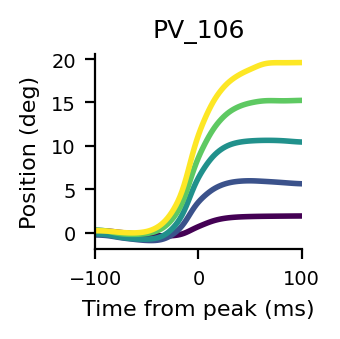

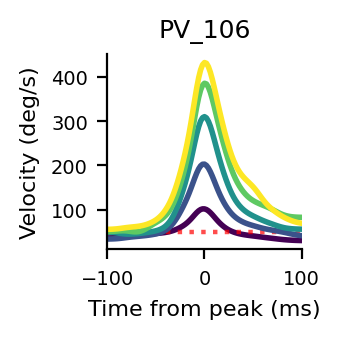

In [38]:
export_path = pathlib.Path(r'Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\Figure_3\materials\pos_vel_traces')

figs, bundle = plot_pos_and_vel_by_amp_bins_per_animal_kernel(
    all_saccade_collection.query('animal=="PV_106"'),
    block_dict,
    bin_width_deg=5.0,
    min_amp_deg=0.5,
    t_window_ms=(-100.0, 100.0),
    dt_ms=2.0,
    bandwidth_ms=10.0,
    min_events_per_bin=30,
    per_animal_max_bins=8,
    eye_filter=None,
    subsample_peak=False,
    smoothing=True,
    normalize_velocity_to_peak=False,
    normalize_position_to_amp=False,   # classic look: 0→1
    velocity_threshold=50,            # mirrored as a vertical line (time-to-threshold) if normalized
    export_path=export_path,
    show_inline=True,
    normalize_final_curve=False,
    align_to='peak',
    position_calc='mov_axis',
    fig_size=(1.8,1.8),
    velocity_unit='deg/sec'
)


Exported to: Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\Figure_3\materials\peak_v_amplitude_per_animal\amplitude_velocity_linear_fit_2025_10_20_20_06_56


(<Figure size 450x510 with 1 Axes>,
 <Axes: xlabel='Amplitude [deg]', ylabel='Peak V [deg/ms]'>,
 {'PV_106':    amp_lo  amp_hi     n  mean_peak_v
  0     0.0     5.0  5032     0.120375
  1     5.0    10.0  1340     0.242502
  2    10.0    15.0   403     0.371490
  3    15.0    20.0   108     0.456992
  4    20.0    25.0    51     0.508111,
  'PV_126':    amp_lo  amp_hi     n  mean_peak_v
  0     0.0     5.0  5815     0.126534
  1     5.0    10.0  1753     0.241851
  2    10.0    15.0   482     0.326007
  3    15.0    20.0   169     0.420986
  4    20.0    25.0    51     0.441457,
  'PV_143':    amp_lo  amp_hi     n  mean_peak_v
  0     0.0     5.0  2238     0.143446
  1     5.0    10.0   730     0.257574
  2    10.0    15.0   160     0.343865
  3    15.0    20.0    38     0.418390
  4    20.0    25.0    16     0.445180,
  'PV_57':    amp_lo  amp_hi     n  mean_peak_v
  0     0.0     5.0  7814     0.119861
  1     5.0    10.0  2016     0.237993
  2    10.0    15.0   731     0.344383
  3

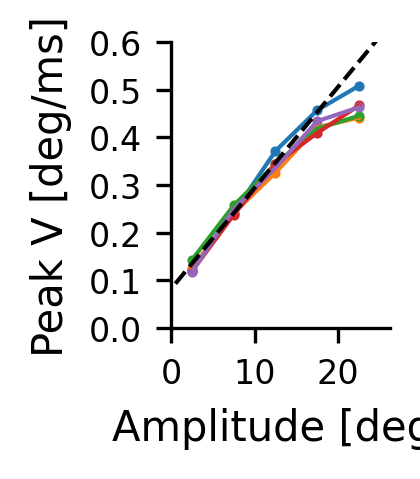

In [21]:
# This is the function for over-animal statictics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.lines as mlines
from typing import Optional, Dict, Any
from pathlib import Path
import pickle, datetime
from scipy import stats

def amplitude_velocity_over_animals_linear_fit(
    all_saccade_collection: pd.DataFrame,
    block_dict: dict,
    amp_col: Optional[str] = None,            # auto: 'net_angular_disp' or 'magnitude_raw_angular'
    eye_filter: Optional[str] = None,         # "L", "R", or None (both)
    bin_width_deg: float = 5.0,
    min_amp_deg: float = 0.5,
    max_amp_pct: float = 99.5,                # clip extreme amplitudes
    min_events_per_bin: int = 15,
    frame_rate_fps: float = 60.0,
    per_animal_color: Optional[dict] = None,  # {"PV_106":"#...", ...}
    figsize=(2.0, 1.7),
    dpi: int = 300,
    lw: float = 1.0,
    export_path: Optional[str] = None
):
    """
    Plots the relationship between saccade amplitude and peak angular velocity
    across animals, using a *linear* fit per animal or globally:

        V_peak = slope * Amplitude + intercept

    Peak velocities are in deg/ms.
    Each animal’s data are binned by amplitude and plotted as connected scatter points.
    A single black dashed line shows the global linear fit.

    Exports to a timestamped directory containing:
        - amplitude_velocity_linear_fit.pdf
        - amplitude_velocity_linear_fit_legend.pdf
        - amplitude_velocity_linear_fit_bundle.pkl
        - amplitude_velocity_linear_fit_stats.csv  (fit parameters, SEs, t, p, R²)

    Axes formatting:
      • Y-ticks start at 0, step by 0.1 (deg/ms)
      • X-axis shows 5 ticks total; labels only at 0, 10, and 20 deg.
    """

    # Helper to ensure directories
    def _ensure_dir(p: Path) -> Path:
        p.mkdir(parents=True, exist_ok=True)
        return p

    df = all_saccade_collection.copy().reset_index(drop=True)
    req = {"animal","block","eye","saccade_on_ms","saccade_off_ms"}
    if not req.issubset(df.columns):
        raise ValueError(f"all_saccade_collection must include columns {req}")

    # choose amplitude column
    if amp_col is None:
        for c in ("net_angular_disp","magnitude_raw_angular"):
            if c in df.columns:
                amp_col = c
                break
    if amp_col is None:
        raise ValueError("Need angular amplitude column: 'net_angular_disp' or 'magnitude_raw_angular'.")

    if eye_filter:
        df = df[df["eye"].astype(str).str.upper() == eye_filter.upper()].copy()

    # ---- compute per-saccade peak velocity in deg/ms ----
    have_profiles = "speed_profile_angular" in df.columns  # deg/frame when present

    def _peak_from_profile(x):
        if x is None or len(x) == 0: return np.nan
        return float(np.nanmax(np.asarray(x, dtype=float)))  # deg/frame

    def _fallback_peak(row):
        try:
            eye_df = _eye_df(block_dict, row["animal"], row["block"], row["eye"])
        except Exception:
            return np.nan
        t_ms, v_dps = _raw_velocity_trace(eye_df)  # deg/s
        if t_ms.size == 0: return np.nan
        m = (t_ms >= float(row["saccade_on_ms"])) & (t_ms <= float(row["saccade_off_ms"])) & np.isfinite(v_dps)
        if not np.any(m): return np.nan
        return float(np.nanmax(v_dps[m]))  # deg/s

    if have_profiles:
        peak_dpf = df["speed_profile_angular"].apply(_peak_from_profile).to_numpy(dtype=float)
        peak_deg_per_ms = peak_dpf * (frame_rate_fps / 1000.0)
    else:
        peak_dps = df.apply(_fallback_peak, axis=1).to_numpy(dtype=float)
        peak_deg_per_ms = peak_dps / 1000.0

    df["peak_velocity"] = peak_deg_per_ms

    # ---- filter ----
    df[amp_col] = pd.to_numeric(df[amp_col], errors="coerce")
    m_valid = np.isfinite(df[amp_col]) & np.isfinite(df["peak_velocity"]) & (df[amp_col] >= float(min_amp_deg))
    df = df[m_valid].copy()
    if df.empty:
        raise ValueError("No saccades after filtering.")

    # ---- amplitude bins ----
    amp_max = float(np.nanpercentile(df[amp_col], max_amp_pct))
    edges = np.arange(0.0, amp_max + bin_width_deg, bin_width_deg)
    if edges.size < 3:
        amp_max = max(amp_max, min_amp_deg + 3*bin_width_deg)
        edges = np.arange(0.0, amp_max + bin_width_deg, bin_width_deg)
    df["amp_bin_idx"] = pd.cut(df[amp_col], bins=edges, labels=False, include_lowest=True, right=False)

    animals = sorted(df["animal"].dropna().unique().tolist())
    per_animal_stats: Dict[str, pd.DataFrame] = {}

    for a in animals:
        sub = df[df["animal"] == a]
        rows = []
        for b in range(len(edges)-1):
            g = sub[sub["amp_bin_idx"] == b]["peak_velocity"].to_numpy(dtype=float)
            g = g[np.isfinite(g)]
            n = g.size
            mean_peak = float(np.nanmean(g)) if n >= min_events_per_bin else np.nan
            rows.append((edges[b], edges[b+1], n, mean_peak))
        per_animal_stats[a] = pd.DataFrame(rows, columns=["amp_lo","amp_hi","n","mean_peak_v"])

    # ---- linear regression with statistics ----
    def _linear_fit_with_stats(x, y):
        m = np.isfinite(x) & np.isfinite(y)
        x = np.asarray(x[m], float); y = np.asarray(y[m], float)
        n = x.size
        if n < 3 or np.allclose(x, x.mean()):
            return dict(n=n, slope=np.nan, intercept=np.nan, R2=np.nan,
                        se_slope=np.nan, t_slope=np.nan, p_slope=np.nan,
                        se_intercept=np.nan, t_intercept=np.nan, p_intercept=np.nan)
        slope, intercept = np.polyfit(x, y, 1)
        yhat = slope * x + intercept
        resid = y - yhat
        ss_res = float(np.sum(resid**2))
        ss_tot = float(np.sum((y - y.mean())**2))
        R2 = 1.0 - ss_res/ss_tot if ss_tot > 0 else np.nan
        dof = n - 2
        s2 = ss_res / dof
        s_xx = float(np.sum((x - x.mean())**2))
        se_slope = np.sqrt(s2 / s_xx)
        se_intercept = np.sqrt(s2 * (1.0/n + (x.mean()**2)/s_xx))
        t_slope = slope / se_slope if se_slope > 0 else np.nan
        p_slope = 2.0 * stats.t.sf(np.abs(t_slope), dof) if np.isfinite(t_slope) else np.nan
        t_intercept = intercept / se_intercept if se_intercept > 0 else np.nan
        p_intercept = 2.0 * stats.t.sf(np.abs(t_intercept), dof) if np.isfinite(t_intercept) else np.nan
        return dict(n=n, slope=slope, intercept=intercept, R2=R2,
                    se_slope=se_slope, t_slope=t_slope, p_slope=p_slope,
                    se_intercept=se_intercept, t_intercept=t_intercept, p_intercept=p_intercept)

    linear_rows = []
    for a in animals:
        sub = df[df["animal"] == a]
        stats_row = _linear_fit_with_stats(sub[amp_col].to_numpy(float), sub["peak_velocity"].to_numpy(float))
        stats_row.update(animal=a)
        linear_rows.append(stats_row)
    linear_stats_df = pd.DataFrame(linear_rows)[
        ["animal","n","slope","se_slope","t_slope","p_slope","intercept","se_intercept","t_intercept","p_intercept","R2"]
    ]

    # ---- global fit for plotting ----
    global_fit = _linear_fit_with_stats(df[amp_col].to_numpy(float), df["peak_velocity"].to_numpy(float))

    # ---- plot ----
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    handles_anim, labels_anim = [], []
    for a in animals:
        S = per_animal_stats[a]
        xs = 0.5*(S["amp_lo"].to_numpy() + S["amp_hi"].to_numpy())
        ys = S["mean_peak_v"].to_numpy()
        m = np.isfinite(xs) & np.isfinite(ys)
        if not np.any(m): continue
        color = per_animal_color.get(a, None) if per_animal_color else None
        ax.scatter(xs[m], ys[m], s=6, linewidths=0, color=color)
        ln, = ax.plot(xs[m], ys[m], lw=lw, color=color, label=a)
        handles_anim.append(ln); labels_anim.append(a)

    # ---- linear fit line ----
    if np.isfinite(global_fit["slope"]) and np.isfinite(global_fit["intercept"]):
        x_line = np.linspace(float(min_amp_deg), float(edges[-1]), 200)
        y_line = global_fit["slope"] * x_line + global_fit["intercept"]
        ax.plot(x_line, y_line, ls='--', lw=lw, color='k', label='Linear fit')

    # ---- cosmetics ----
    ax.set_xlabel("Amplitude [deg]", fontsize=10)
    ax.set_ylabel("Peak V [deg/ms]", fontsize=10)
    ax.tick_params(axis='both', which='major', labelsize=8)
    for sp in ("top","right"): ax.spines[sp].set_visible(False)
    ax.set_xlim(left=0)

    # x-axis: 5 ticks total; labels only at 0,10,20
    ax.set_xticks([0,10,20])
    ax.set_xticklabels(["0","10","20"])

    # y-axis: start at 0 with 0.1 increments
    ydata_max = np.nanmax([np.nanmax(S["mean_peak_v"].to_numpy()) for S in per_animal_stats.values()] + [0.0])
    y_top = 0.1 * np.ceil((ydata_max if np.isfinite(ydata_max) else 0.0) / 0.1)
    y_top = max(y_top, 0.1)
    ax.set_ylim(0.0, y_top)
    ax.set_yticks(np.arange(0.0, y_top + 1e-9, 0.1))
    fig.tight_layout()

    # ---- export ----
    if export_path:
        ts = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
        out_dir = _ensure_dir(Path(export_path) / f"amplitude_velocity_linear_fit_{ts}")

        fig.savefig(out_dir / "amplitude_velocity_linear_fit.pdf", bbox_inches="tight", dpi=dpi)
        powerlaw_item = mlines.Line2D([], [], ls='--', lw=lw, color='k', label='Linear fit')
        leg_items = handles_anim + [powerlaw_item]
        leg_labels = labels_anim + ['Linear fit']
        fig_leg = plt.figure(figsize=(2.0, 1.7), dpi=dpi)
        fig_leg.legend(leg_items, leg_labels, frameon=False, ncol=1, fontsize=8, loc="center")
        fig_leg.savefig(out_dir / "amplitude_velocity_linear_fit_legend.pdf", bbox_inches="tight", dpi=dpi)
        plt.close(fig_leg)

        bundle = dict(
            params=dict(amp_col=amp_col, bin_width_deg=bin_width_deg, min_amp_deg=min_amp_deg,
                        max_amp_pct=max_amp_pct, min_events_per_bin=min_events_per_bin,
                        frame_rate_fps=frame_rate_fps, figsize=figsize, dpi=dpi, lw=lw),
            edges=edges,
            per_animal_stats=per_animal_stats,
            global_fit=global_fit,
            linear_stats_df=linear_stats_df
        )
        with open(out_dir / "amplitude_velocity_linear_fit_bundle.pkl", "wb") as f:
            pickle.dump(bundle, f)
        linear_stats_df.to_csv(out_dir / "amplitude_velocity_linear_fit_stats.csv", index=False)
        print(f"Exported to: {out_dir}")

    return fig, ax, per_animal_stats, global_fit, linear_stats_df

export_path = r'Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\Figure_3\materials\peak_v_amplitude_per_animal'
amplitude_velocity_over_animals_linear_fit(
    all_saccade_collection,
    block_dict,
    bin_width_deg=5.0,
    export_path=export_path,
    figsize=(1.5, 1.7)
)